# XGBoost results Using Smote and Standarscaler
Best Threshold: 0.48775604

Accuracy : 0.5844270323212537

Precision: 0.38209171651259743

Recall   : 0.7165193745751189

F1 Score : 0.49840406667454784

ROC-AUC  : 0.6678402144262567


In [3]:
import pandas as pd 
import  numpy as np
import matplotlib as plt

In [4]:
dt=pd.read_csv('cell2celltrain.csv')

In [5]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

In [6]:
dt.describe()

,CustomerID,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,...,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,RetentionCalls,RetentionOffersAccepted,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating
count,5.104700e+04,50891.000000,50891.000000,50891.000000,50891.000000,50891.000000,50891.000000,50680.000000,50680.000000,51047.000000,...,51046.000000,51046.000000,51046.000000,50138.000000,50138.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000
mean,3.201957e+06,58.834492,525.653416,46.830088,0.895229,40.027785,1.236244,-11.547908,-1.191985,6.011489,...,1.805646,1.558751,380.545841,31.338127,21.144142,0.037201,0.018277,0.052070,4.324524,0.053911
std,1.169056e+05,44.507336,529.871063,23.848871,2.228546,96.588076,9.818294,257.514772,39.574915,9.043955,...,1.331173,0.905932,253.801982,22.094635,23.931368,0.206483,0.142458,0.307592,3.138236,0.383147
min,3.000002e+06,-6.170000,0.000000,-11.000000,0.000000,0.000000,0.000000,-3875.000000,-1107.700000,0.000000,...,1.000000,1.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.100632e+06,33.610000,158.000000,30.000000,0.000000,0.000000,0.000000,-83.000000,-7.100000,0.700000,...,1.000000,1.000000,205.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.201534e+06,48.460000,366.000000,45.000000,0.250000,3.000000,0.000000,-5.000000,-0.300000,3.000000,...,1.000000,1.000000,329.000000,36.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000
75%,3.305376e+06,71.065000,723.000000,60.000000,0.990000,41.000000,0.300000,66.000000,1.600000,7.700000,...,2.000000,2.000000,515.000000,48.000000,42.000000,0.000000,0.000000,0.000000,7.000000,0.000000
max,3.399994e+06,1223.380000,7359.000000,400.000000,159.390000,4321.000000,1112.400000,5192.000000,2483.500000,221.700000,...,24.000000,15.000000,1812.000000,99.000000,99.000000,4.000000,3.000000,35.000000,9.000000,25.000000


In [7]:
dt.isnull().sum()

CustomerID                     0
Churn                          0
MonthlyRevenue               156
MonthlyMinutes               156
TotalRecurringCharge         156
DirectorAssistedCalls        156
OverageMinutes               156
RoamingCalls                 156
PercChangeMinutes            367
PercChangeRevenues           367
DroppedCalls                   0
BlockedCalls                   0
UnansweredCalls                0
CustomerCareCalls              0
ThreewayCalls                  0
ReceivedCalls                  0
OutboundCalls                  0
InboundCalls                   0
PeakCallsInOut                 0
OffPeakCallsInOut              0
DroppedBlockedCalls            0
CallForwardingCalls            0
CallWaitingCalls               0
MonthsInService                0
UniqueSubs                     0
ActiveSubs                     0
ServiceArea                   24
Handsets                       1
HandsetModels                  1
CurrentEquipmentDays           1
AgeHH1    

In [8]:
dt.head(100)

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,3000646,No,108.72,1228.0,108.0,0.74,0.0,0.0,-12.0,-0.7,...,0,4,No,0,150,No,1-Highest,Other,Other,Yes
96,3000654,No,32.27,112.0,32.0,0.00,0.0,0.0,-2.0,-0.3,...,0,4,No,1,30,No,1-Highest,Other,Other,Yes
97,3000674,No,43.72,245.0,30.0,0.00,30.0,0.0,53.0,7.0,...,0,3,No,0,150,No,1-Highest,Other,Other,No
98,3000678,No,65.94,572.0,59.0,0.00,45.0,1.5,-119.0,-15.6,...,0,0,No,1,80,No,3-Good,Other,Other,Unknown


In [9]:
dt.shape

(51047, 58)

In [10]:
!pip install --upgrade pip
!pip install --upgrade numpy==1.26.4 scipy==1.12.0 scikit-learn==1.5.2 imbalanced-learn==0.12.3


In [11]:
import numpy as np

# numeric columns
num_cols = dt.select_dtypes(include=['float64', 'int64']).columns

# categorical columns
cat_cols = dt.select_dtypes(include=['object']).columns

# impute numeric
dt[num_cols] = dt[num_cols].fillna(dt[num_cols].median())

# impute categorical
dt[cat_cols] = dt[cat_cols].fillna(dt[cat_cols].mode().iloc[0])


In [12]:
dt.isnull().sum()

CustomerID                   0
Churn                        0
MonthlyRevenue               0
MonthlyMinutes               0
TotalRecurringCharge         0
DirectorAssistedCalls        0
OverageMinutes               0
RoamingCalls                 0
PercChangeMinutes            0
PercChangeRevenues           0
DroppedCalls                 0
BlockedCalls                 0
UnansweredCalls              0
CustomerCareCalls            0
ThreewayCalls                0
ReceivedCalls                0
OutboundCalls                0
InboundCalls                 0
PeakCallsInOut               0
OffPeakCallsInOut            0
DroppedBlockedCalls          0
CallForwardingCalls          0
CallWaitingCalls             0
MonthsInService              0
UniqueSubs                   0
ActiveSubs                   0
ServiceArea                  0
Handsets                     0
HandsetModels                0
CurrentEquipmentDays         0
AgeHH1                       0
AgeHH2                       0
Children

In [13]:
dt.describe()


,CustomerID,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,...,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,RetentionCalls,RetentionOffersAccepted,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating
count,5.104700e+04,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,...,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000
mean,3.201957e+06,58.802788,525.165514,46.824495,0.893257,39.914628,1.232466,-11.500833,-1.185572,6.011489,...,1.805630,1.558740,380.544831,31.421141,20.767626,0.037201,0.018277,0.052070,4.324524,0.053911
std,1.169056e+05,44.442964,529.134170,23.812615,2.225423,96.462028,9.803517,256.587986,39.432467,9.043955,...,1.331165,0.905927,253.799599,21.905705,23.881611,0.206483,0.142458,0.307592,3.138236,0.383147
min,3.000002e+06,-6.170000,0.000000,-11.000000,0.000000,0.000000,0.000000,-3875.000000,-1107.700000,0.000000,...,1.000000,1.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.100632e+06,33.660000,159.000000,30.000000,0.000000,0.000000,0.000000,-82.000000,-6.900000,0.700000,...,1.000000,1.000000,205.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.201534e+06,48.460000,366.000000,45.000000,0.250000,3.000000,0.000000,-5.000000,-0.300000,3.000000,...,1.000000,1.000000,329.000000,36.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000
75%,3.305376e+06,70.960000,722.000000,60.000000,0.990000,40.000000,0.200000,65.000000,1.550000,7.700000,...,2.000000,2.000000,515.000000,48.000000,42.000000,0.000000,0.000000,0.000000,7.000000,0.000000
max,3.399994e+06,1223.380000,7359.000000,400.000000,159.390000,4321.000000,1112.400000,5192.000000,2483.500000,221.700000,...,24.000000,15.000000,1812.000000,99.000000,99.000000,4.000000,3.000000,35.000000,9.000000,25.000000


In [14]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             51047 non-null  float64
 3   MonthlyMinutes             51047 non-null  float64
 4   TotalRecurringCharge       51047 non-null  float64
 5   DirectorAssistedCalls      51047 non-null  float64
 6   OverageMinutes             51047 non-null  float64
 7   RoamingCalls               51047 non-null  float64
 8   PercChangeMinutes          51047 non-null  float64
 9   PercChangeRevenues         51047 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo


Processing Column: CustomerID

=== Outlier Report for: CustomerID ===
Lower Bound: 2793516.00
Upper Bound: 3612492.00
Total Outliers: 0
Rows before: 51047, Rows after: 51047


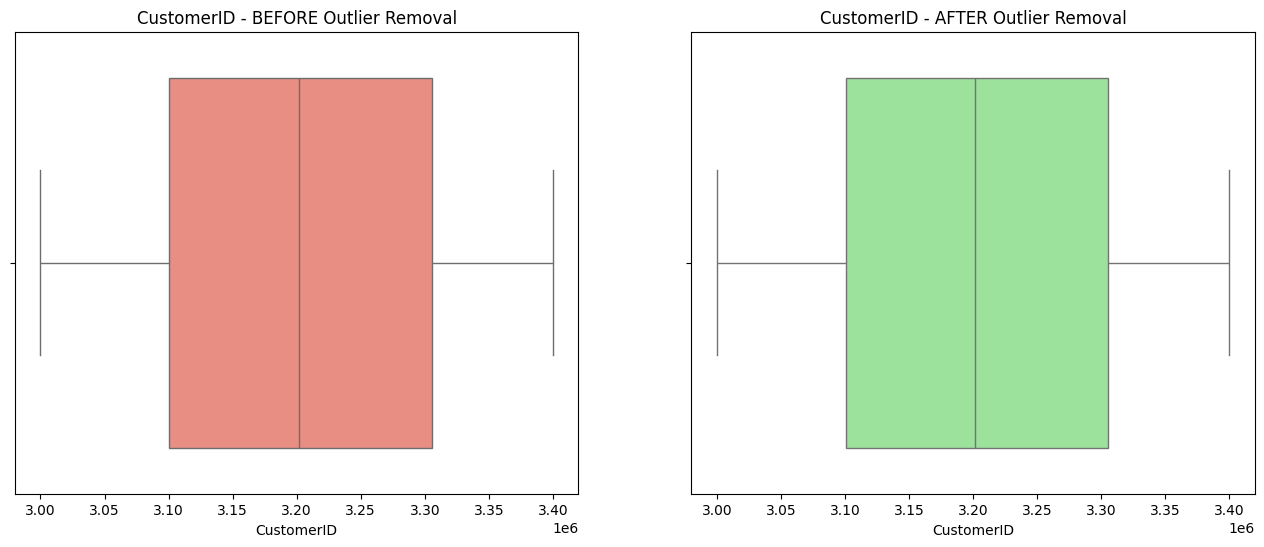


Processing Column: MonthlyRevenue

=== Outlier Report for: MonthlyRevenue ===
Lower Bound: -22.29
Upper Bound: 126.91
Total Outliers: 3009
Rows before: 51047, Rows after: 48038


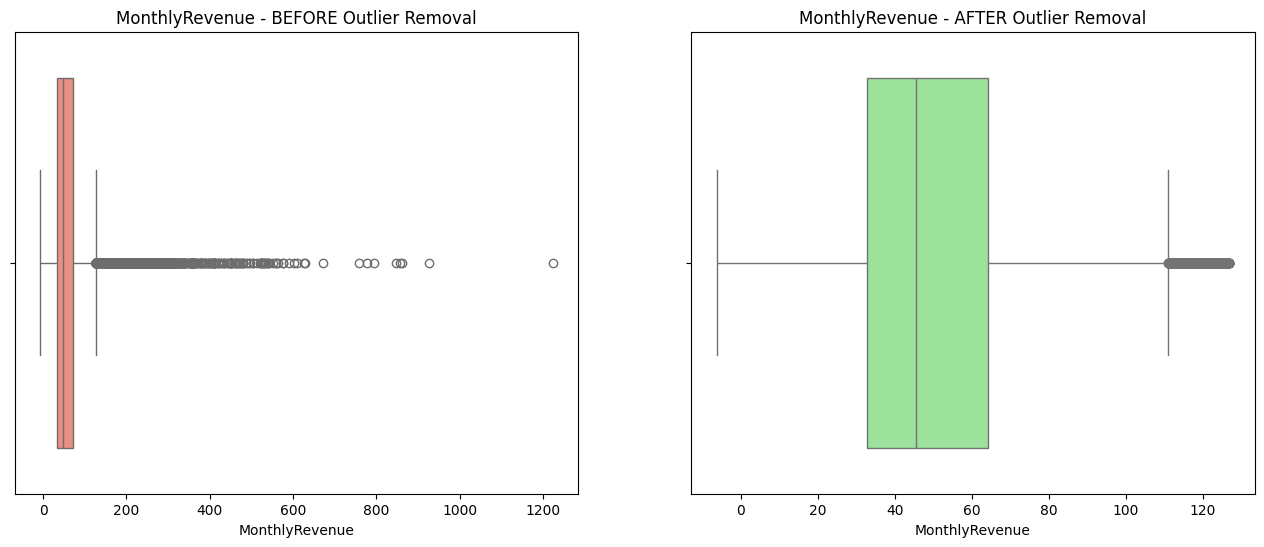


Processing Column: MonthlyMinutes

=== Outlier Report for: MonthlyMinutes ===
Lower Bound: -590.00
Upper Bound: 1378.00
Total Outliers: 2037
Rows before: 48038, Rows after: 46001


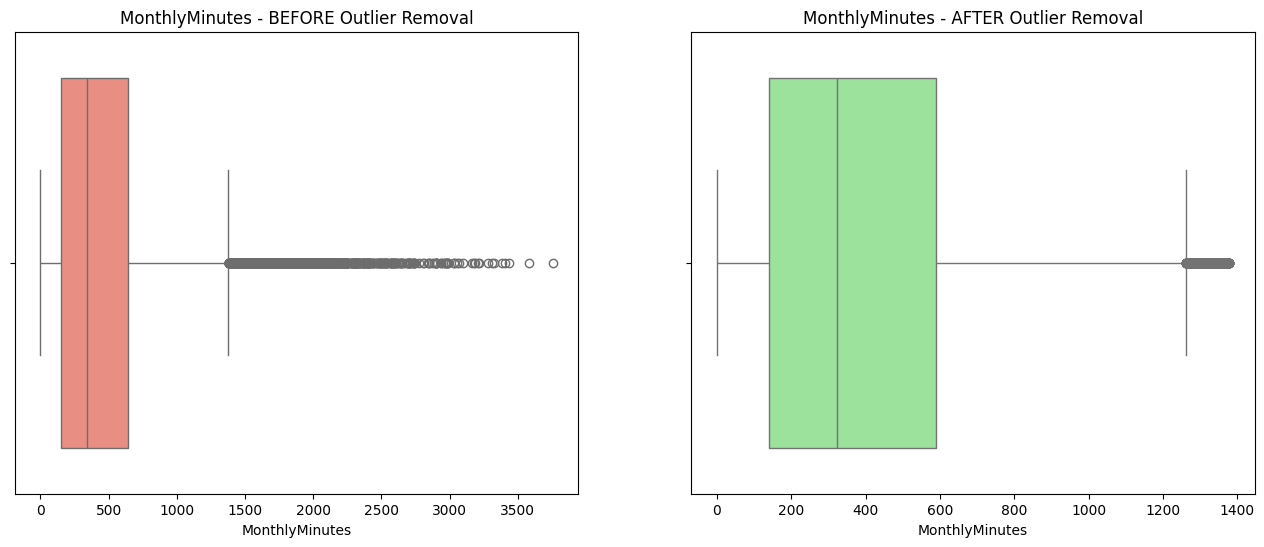


Processing Column: TotalRecurringCharge

=== Outlier Report for: TotalRecurringCharge ===
Lower Bound: -4.50
Upper Bound: 87.50
Total Outliers: 1032
Rows before: 46001, Rows after: 44969


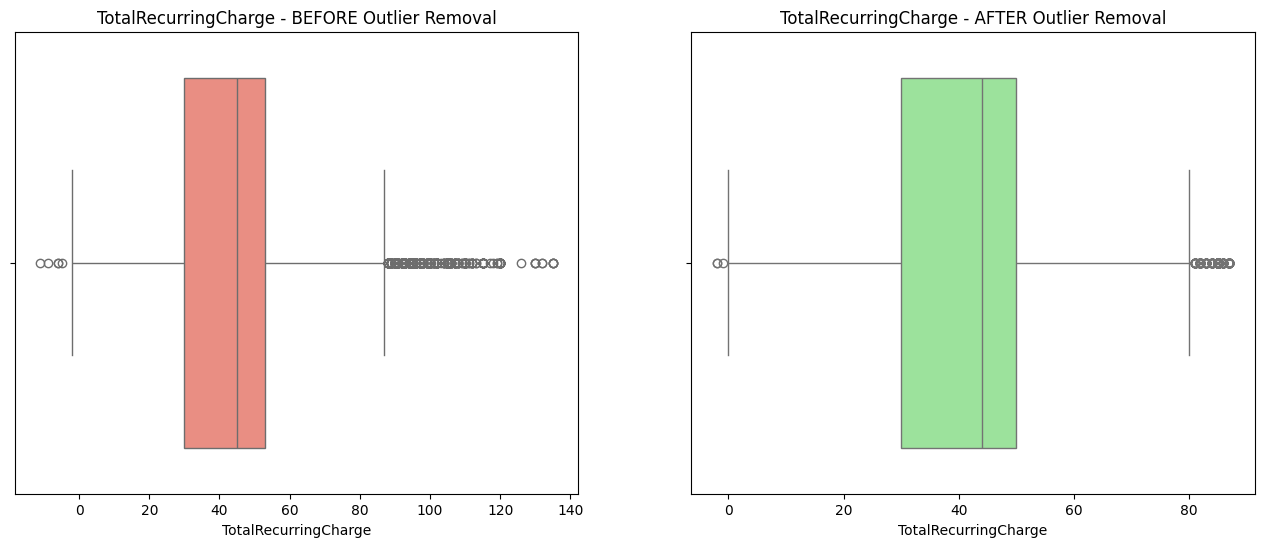


Processing Column: DirectorAssistedCalls

=== Outlier Report for: DirectorAssistedCalls ===
Lower Bound: -1.11
Upper Bound: 1.85
Total Outliers: 4679
Rows before: 44969, Rows after: 40290


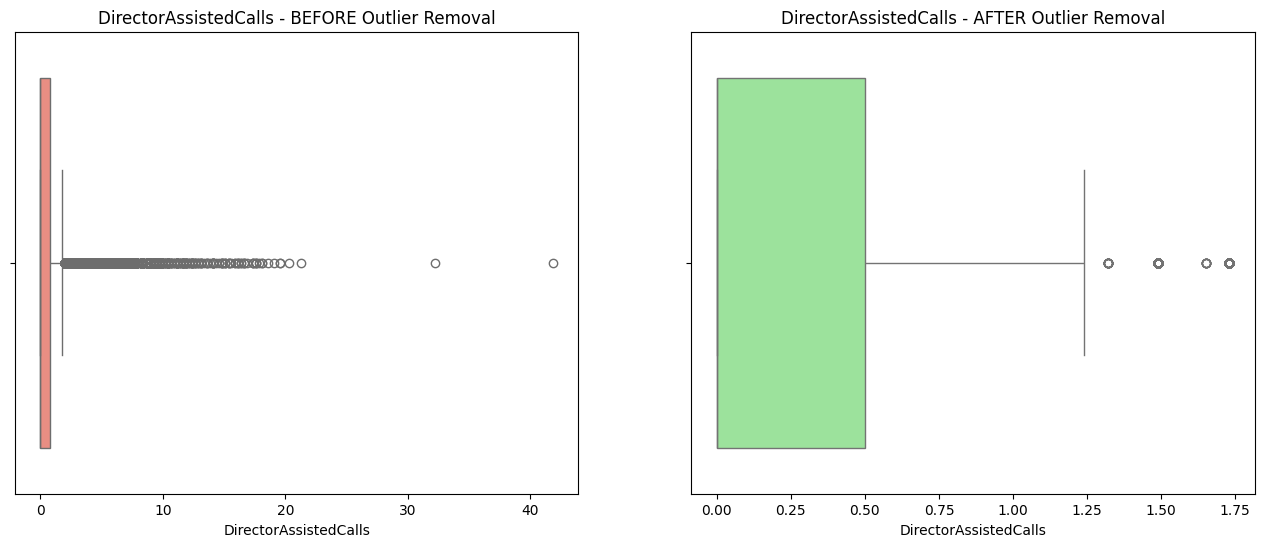


Processing Column: OverageMinutes

=== Outlier Report for: OverageMinutes ===
Lower Bound: -36.00
Upper Bound: 60.00
Total Outliers: 4860
Rows before: 40290, Rows after: 35430


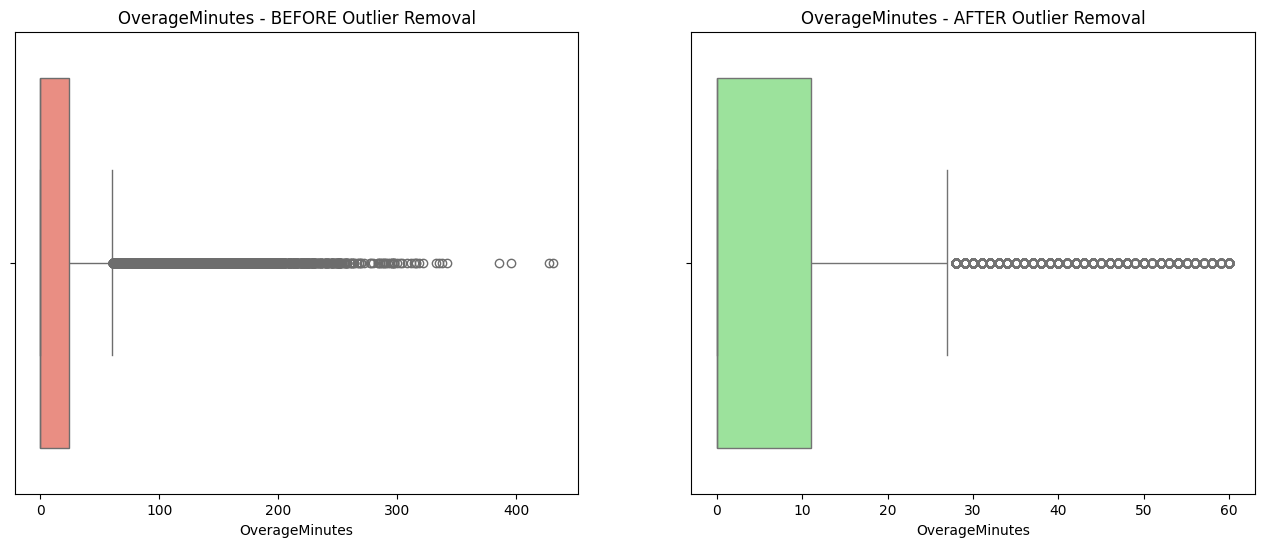


Processing Column: RoamingCalls

=== Outlier Report for: RoamingCalls ===
Lower Bound: -0.15
Upper Bound: 0.25
Total Outliers: 7539
Rows before: 35430, Rows after: 27891


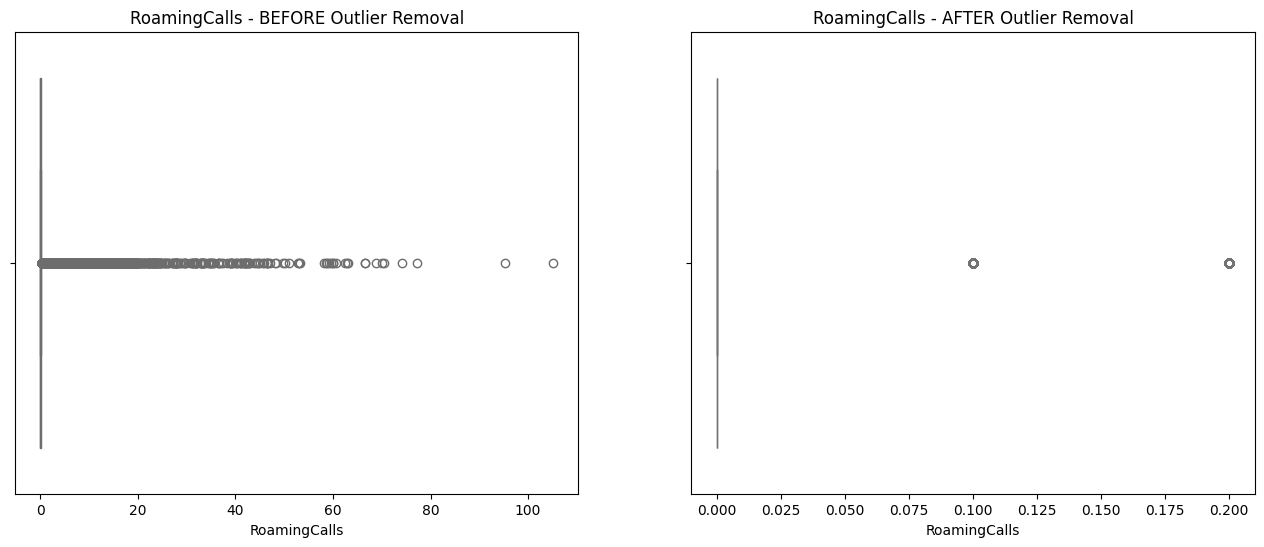


Processing Column: PercChangeMinutes

=== Outlier Report for: PercChangeMinutes ===
Lower Bound: -196.50
Upper Bound: 183.50
Total Outliers: 3505
Rows before: 27891, Rows after: 24386


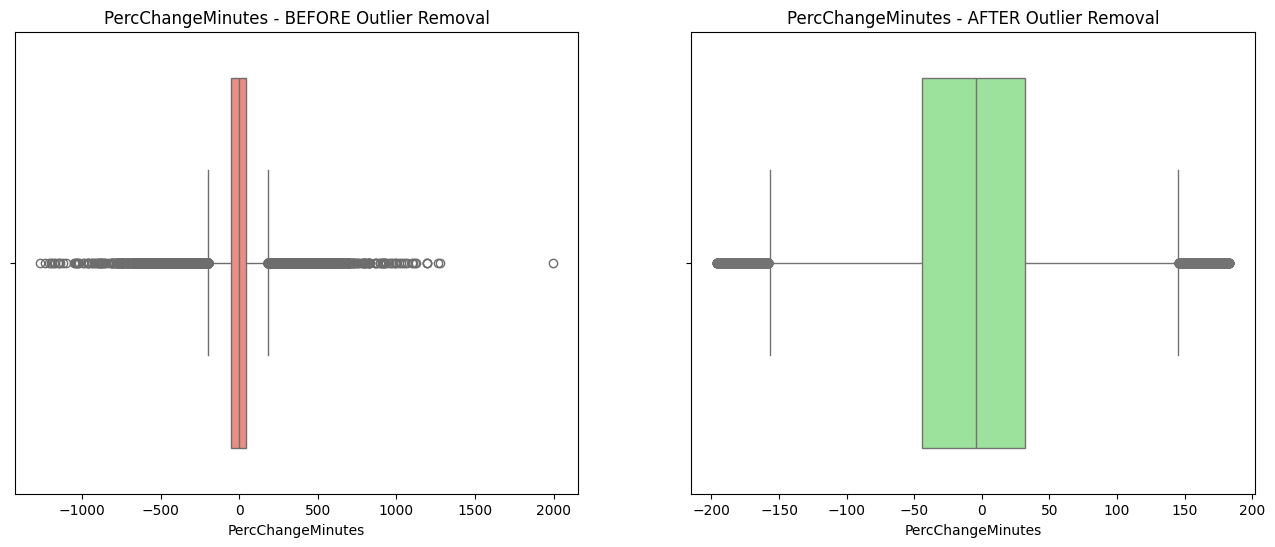


Processing Column: PercChangeRevenues

=== Outlier Report for: PercChangeRevenues ===
Lower Bound: -4.50
Upper Bound: 2.70
Total Outliers: 7350
Rows before: 24386, Rows after: 17036


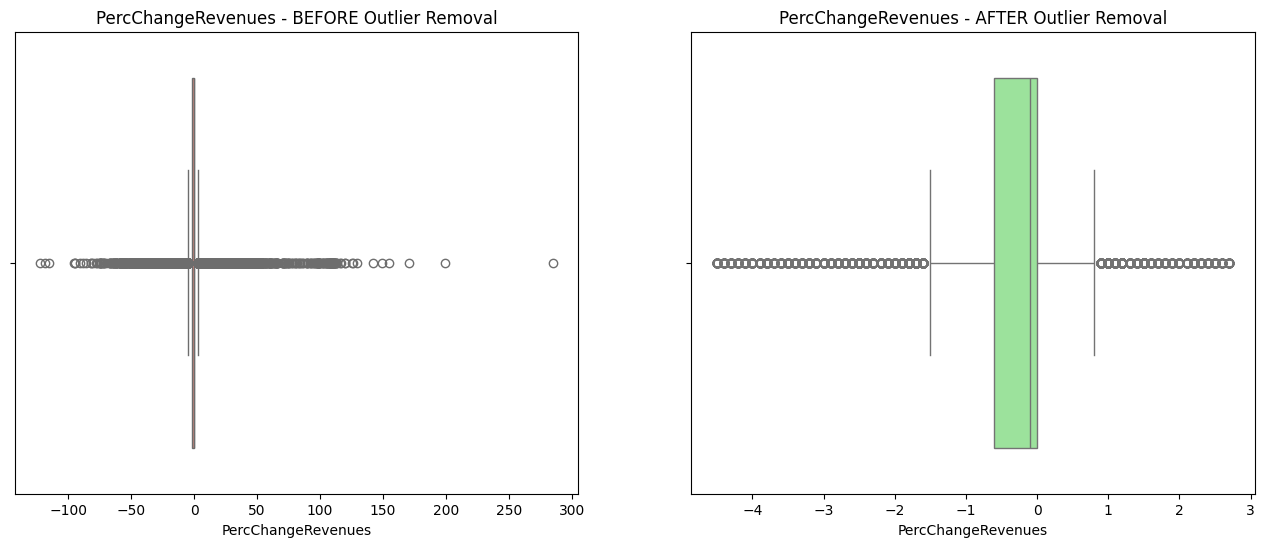


Processing Column: DroppedCalls

=== Outlier Report for: DroppedCalls ===
Lower Bound: -5.55
Upper Bound: 9.25
Total Outliers: 1141
Rows before: 17036, Rows after: 15895


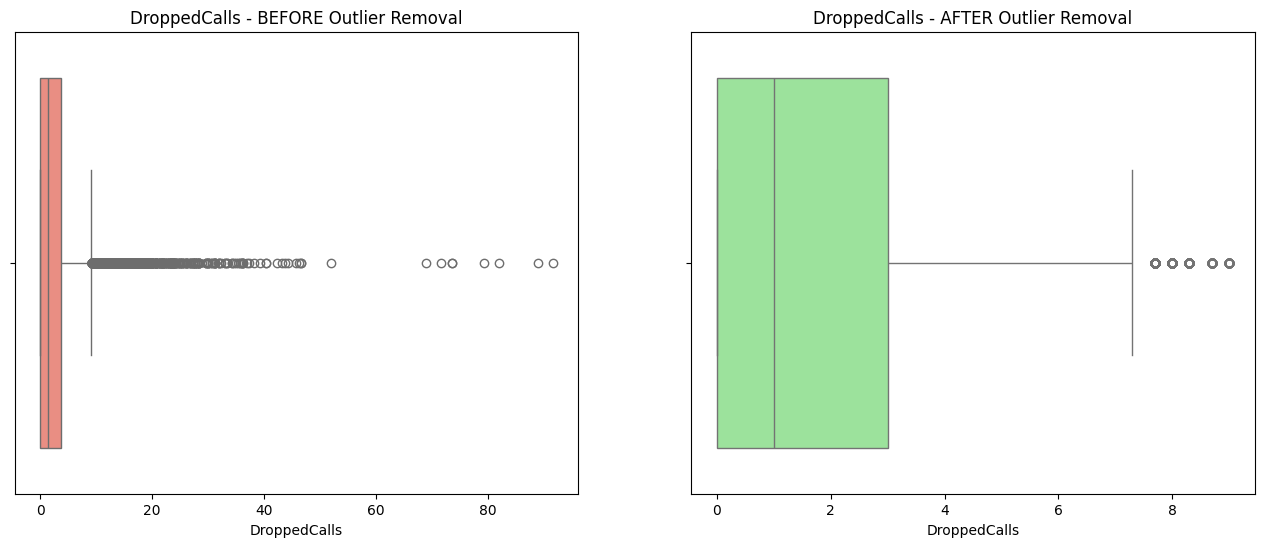


Processing Column: BlockedCalls

=== Outlier Report for: BlockedCalls ===
Lower Bound: -2.55
Upper Bound: 4.25
Total Outliers: 1645
Rows before: 15895, Rows after: 14250


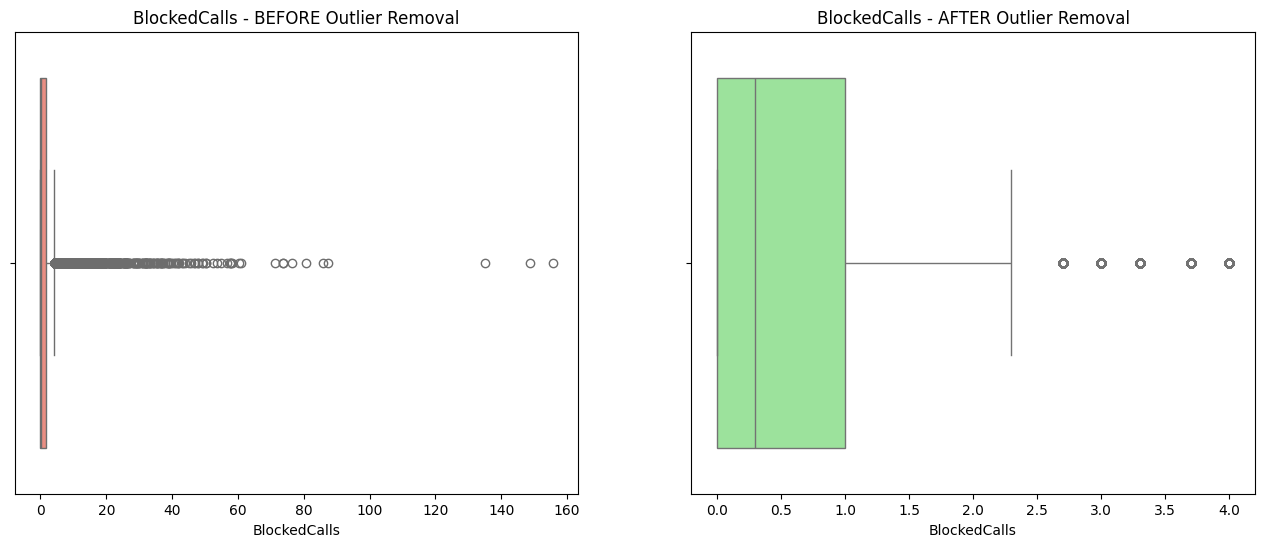


Processing Column: UnansweredCalls

=== Outlier Report for: UnansweredCalls ===
Lower Bound: -18.20
Upper Bound: 33.80
Total Outliers: 770
Rows before: 14250, Rows after: 13480


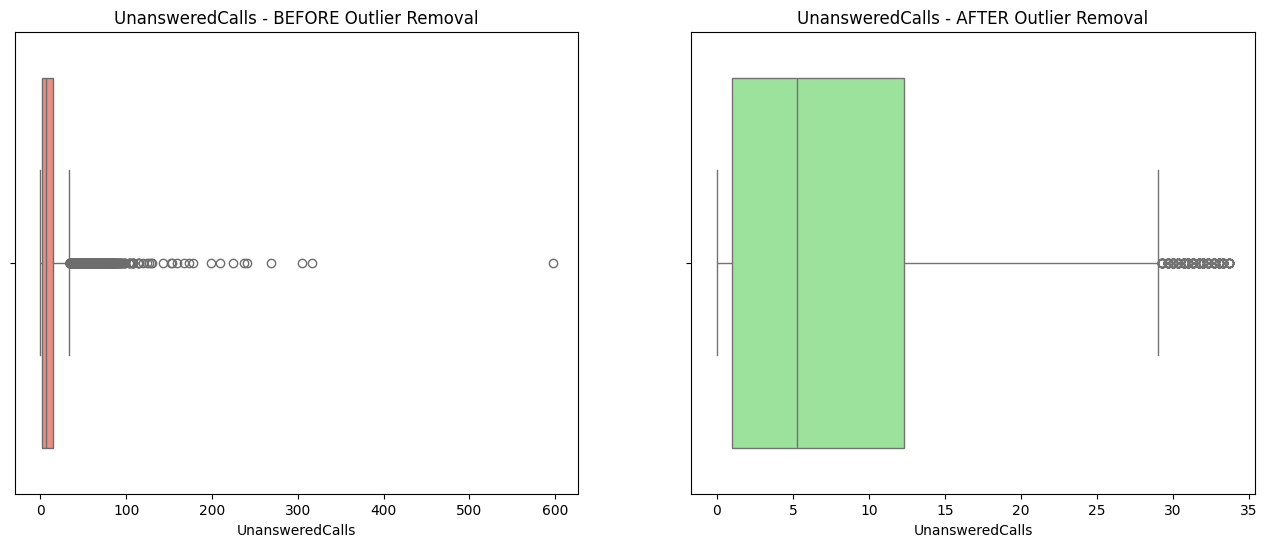


Processing Column: CustomerCareCalls

=== Outlier Report for: CustomerCareCalls ===
Lower Bound: 0.00
Upper Bound: 0.00
Total Outliers: 2896
Rows before: 13480, Rows after: 10584


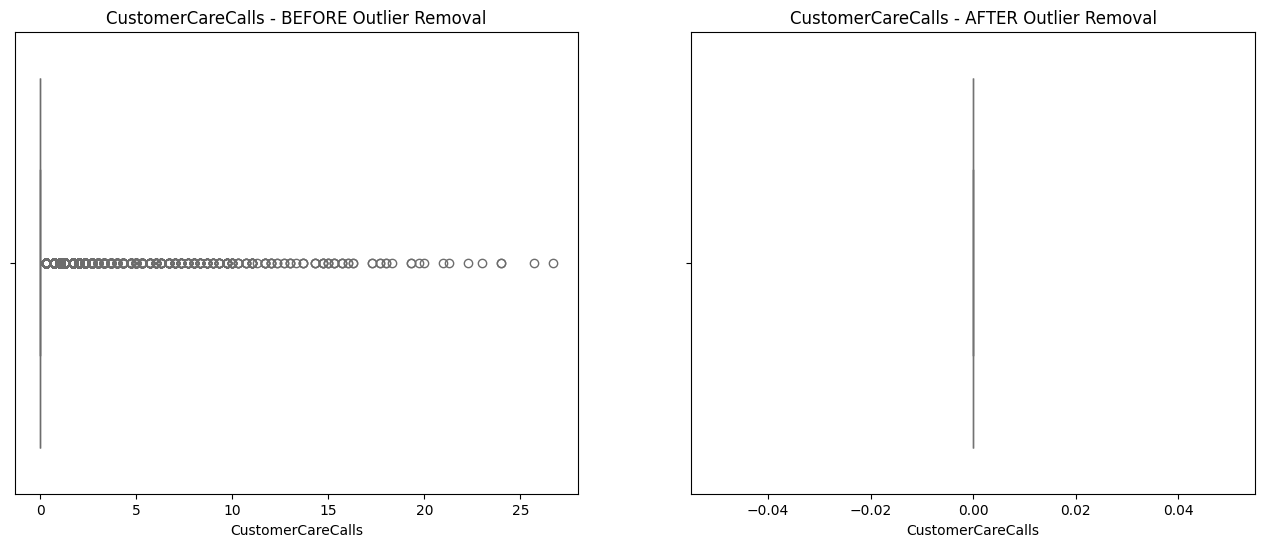


Processing Column: ThreewayCalls

=== Outlier Report for: ThreewayCalls ===
Lower Bound: 0.00
Upper Bound: 0.00
Total Outliers: 1081
Rows before: 10584, Rows after: 9503


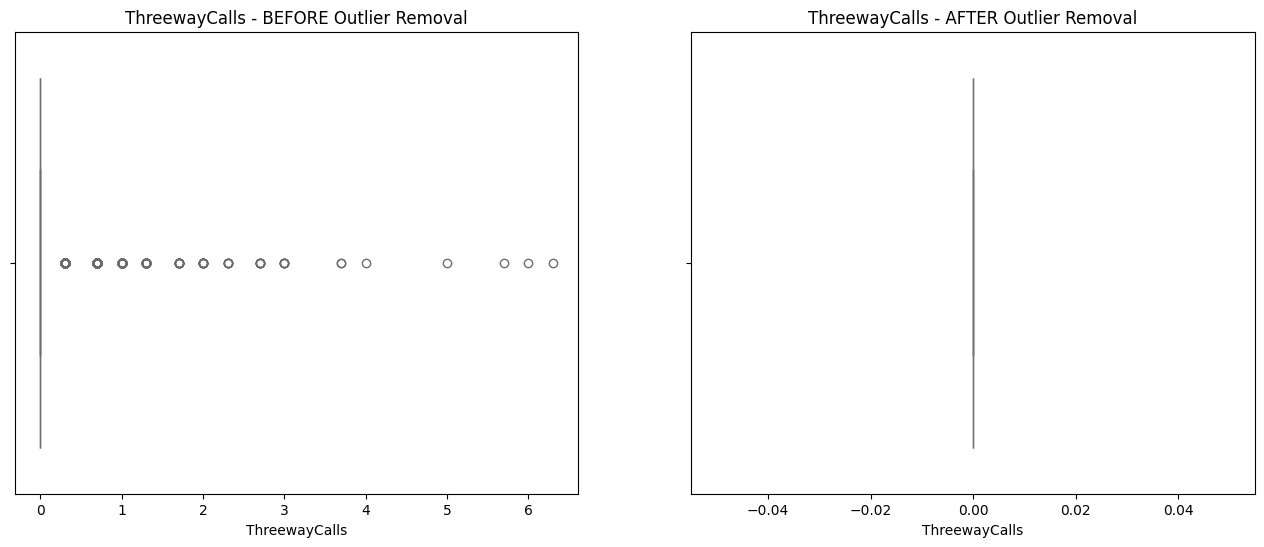


Processing Column: ReceivedCalls

=== Outlier Report for: ReceivedCalls ===
Lower Bound: -32.70
Upper Bound: 54.50
Total Outliers: 1067
Rows before: 9503, Rows after: 8436


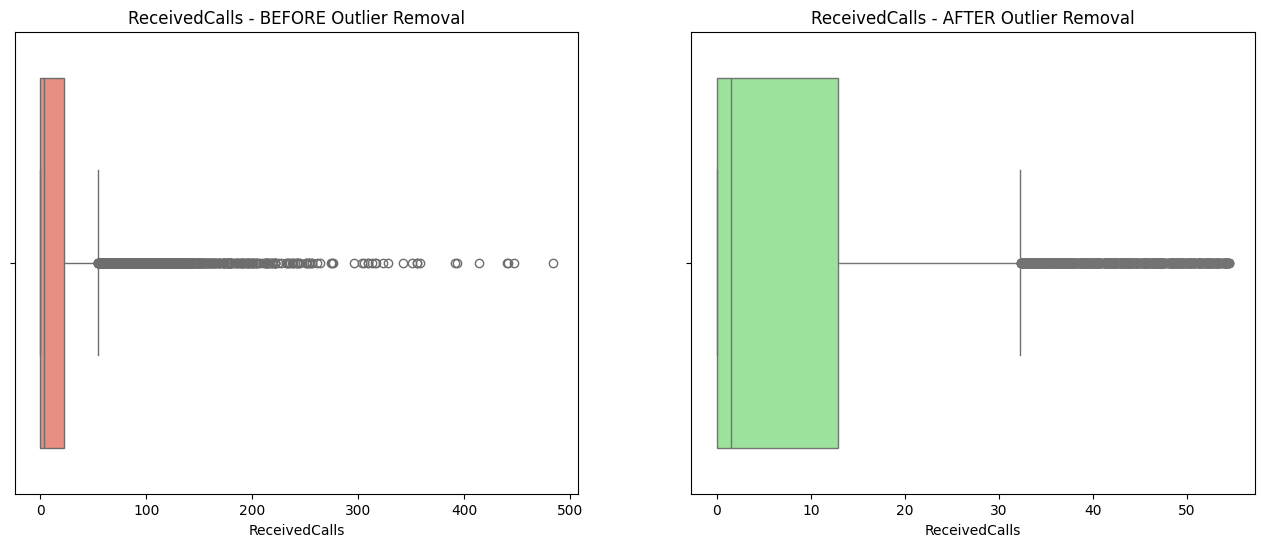


Processing Column: OutboundCalls

=== Outlier Report for: OutboundCalls ===
Lower Bound: -7.95
Upper Bound: 13.25
Total Outliers: 678
Rows before: 8436, Rows after: 7758


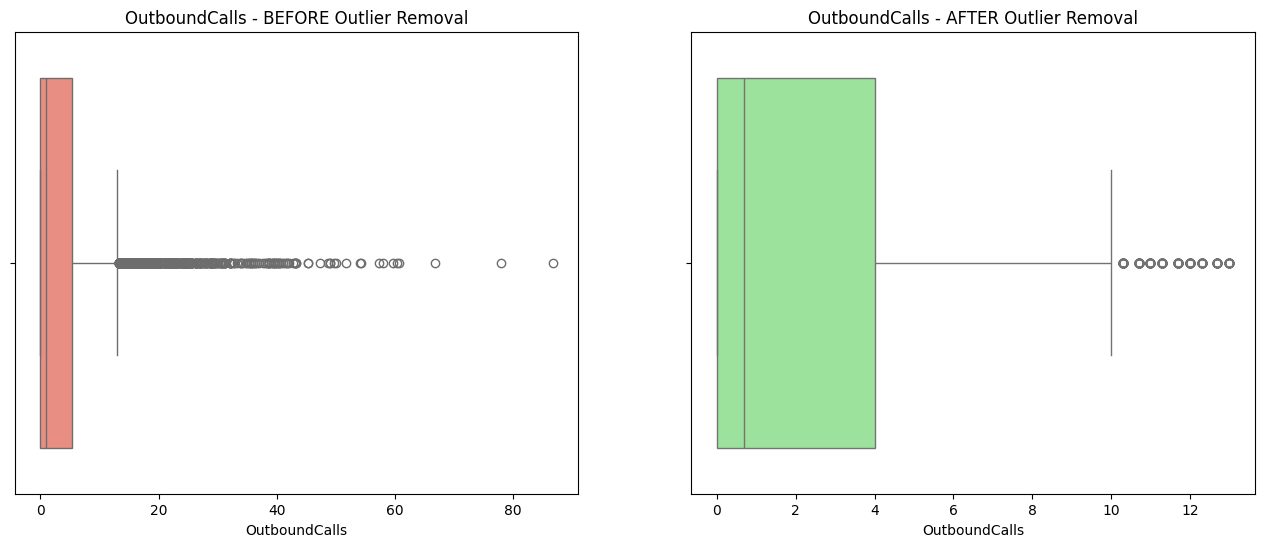


Processing Column: InboundCalls

=== Outlier Report for: InboundCalls ===
Lower Bound: -0.45
Upper Bound: 0.75
Total Outliers: 1440
Rows before: 7758, Rows after: 6318


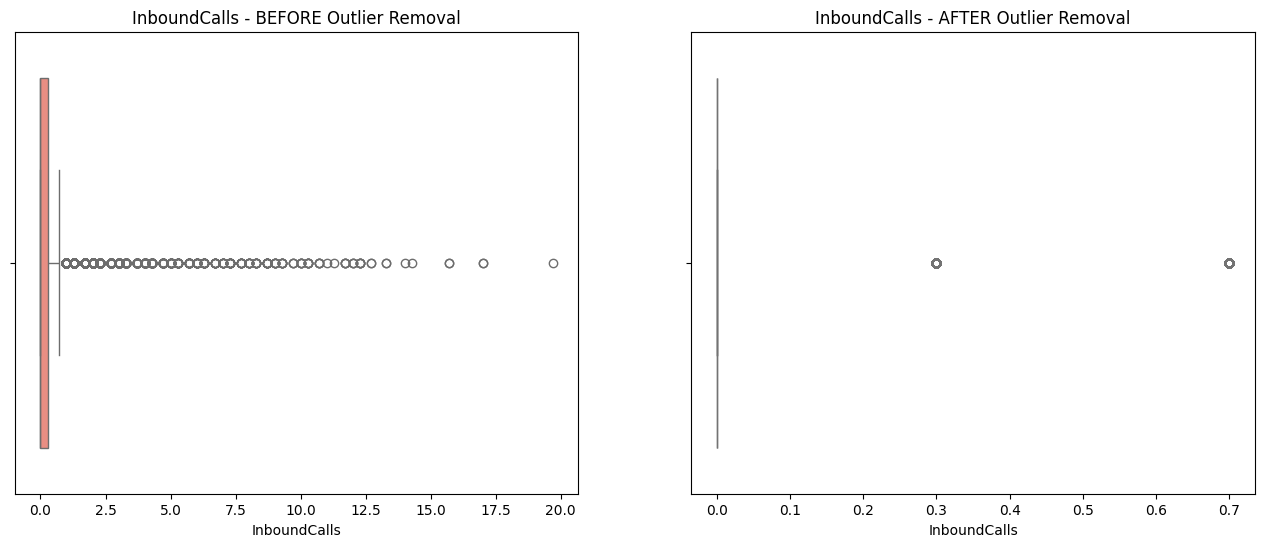


Processing Column: PeakCallsInOut

=== Outlier Report for: PeakCallsInOut ===
Lower Bound: -25.05
Upper Bound: 41.75
Total Outliers: 317
Rows before: 6318, Rows after: 6001


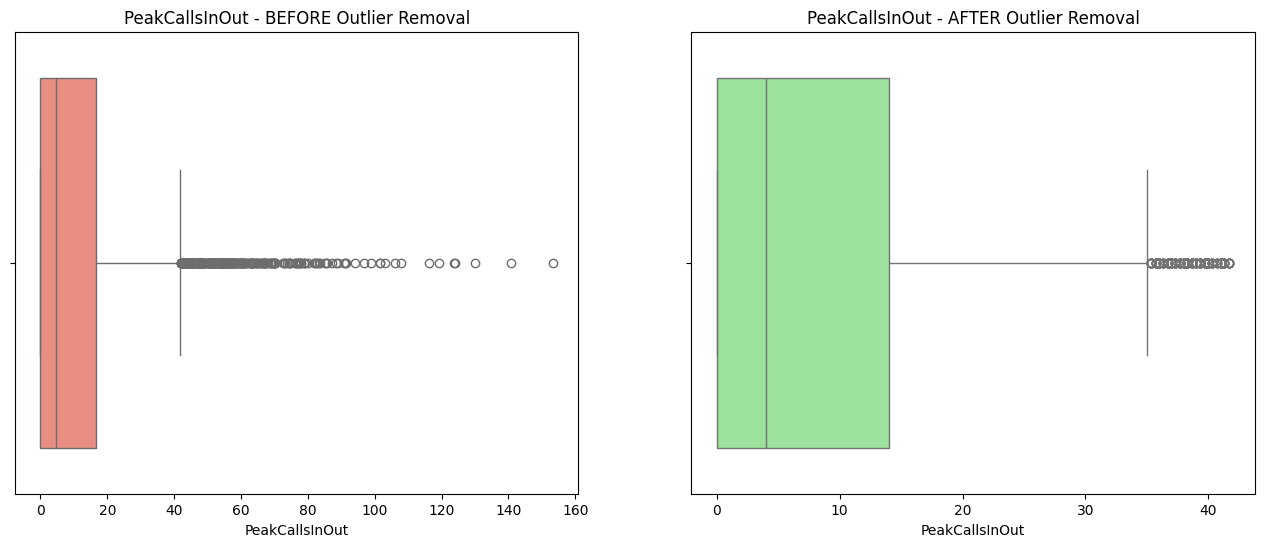


Processing Column: OffPeakCallsInOut

=== Outlier Report for: OffPeakCallsInOut ===
Lower Bound: -10.50
Upper Bound: 17.50
Total Outliers: 410
Rows before: 6001, Rows after: 5591


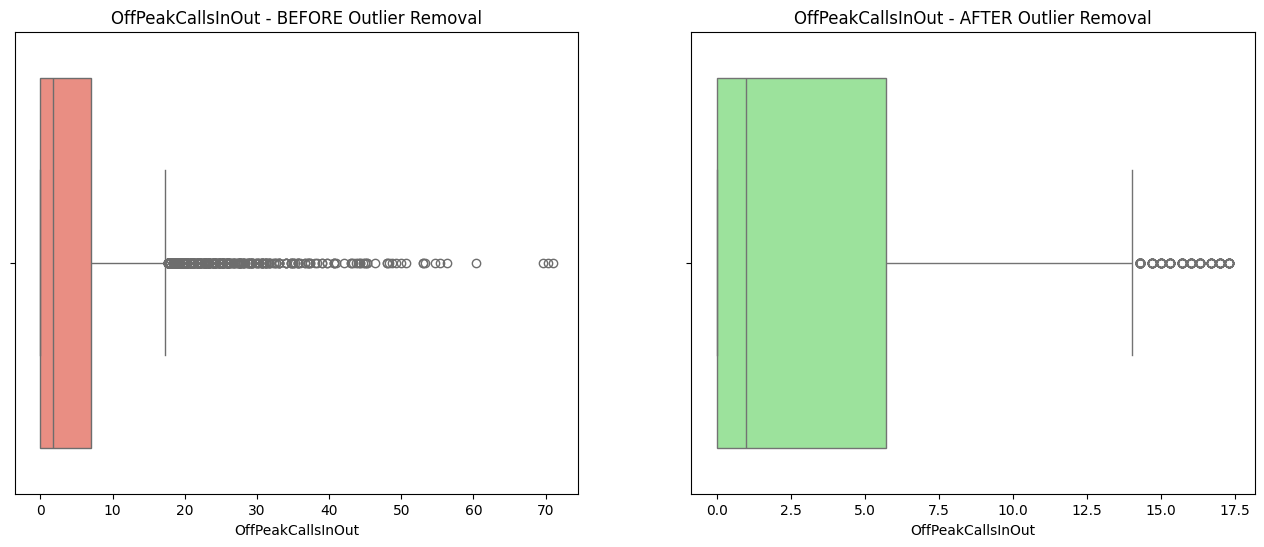


Processing Column: DroppedBlockedCalls

=== Outlier Report for: DroppedBlockedCalls ===
Lower Bound: -1.95
Upper Bound: 3.25
Total Outliers: 343
Rows before: 5591, Rows after: 5248


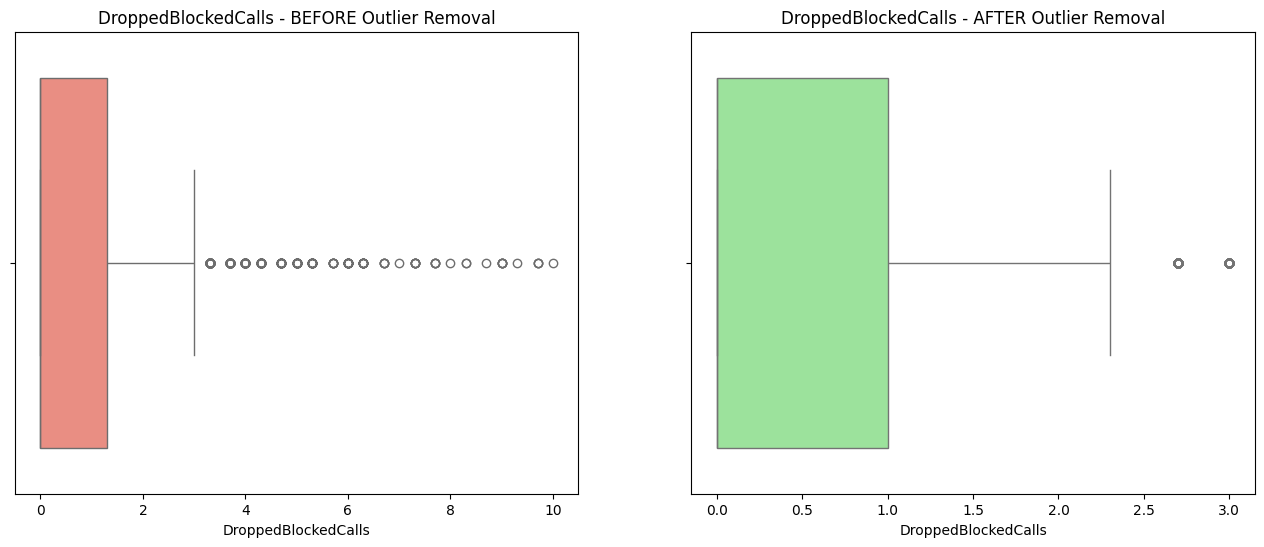


Processing Column: CallForwardingCalls

=== Outlier Report for: CallForwardingCalls ===
Lower Bound: 0.00
Upper Bound: 0.00
Total Outliers: 1
Rows before: 5248, Rows after: 5247


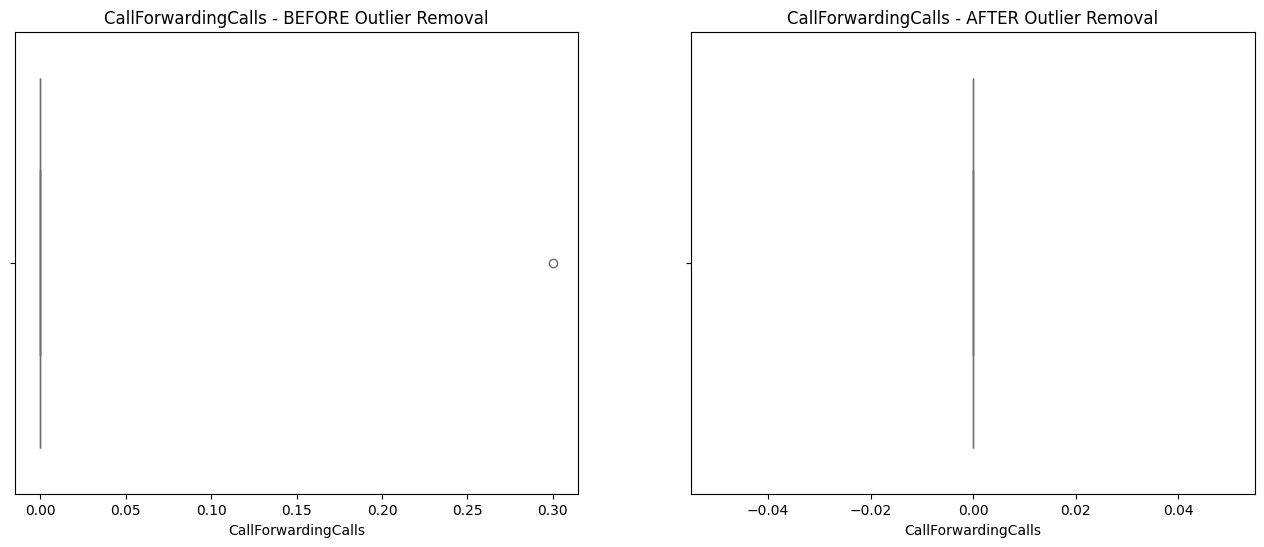


Processing Column: CallWaitingCalls

=== Outlier Report for: CallWaitingCalls ===
Lower Bound: 0.00
Upper Bound: 0.00
Total Outliers: 182
Rows before: 5247, Rows after: 5065


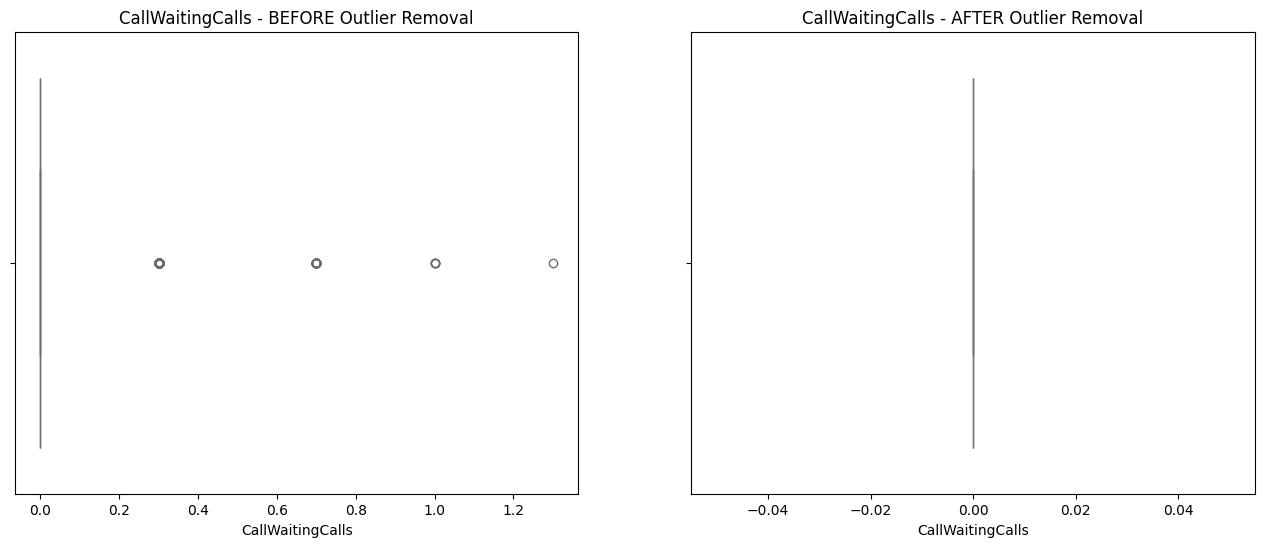


Processing Column: MonthsInService

=== Outlier Report for: MonthsInService ===
Lower Bound: -10.50
Upper Bound: 49.50
Total Outliers: 107
Rows before: 5065, Rows after: 4958


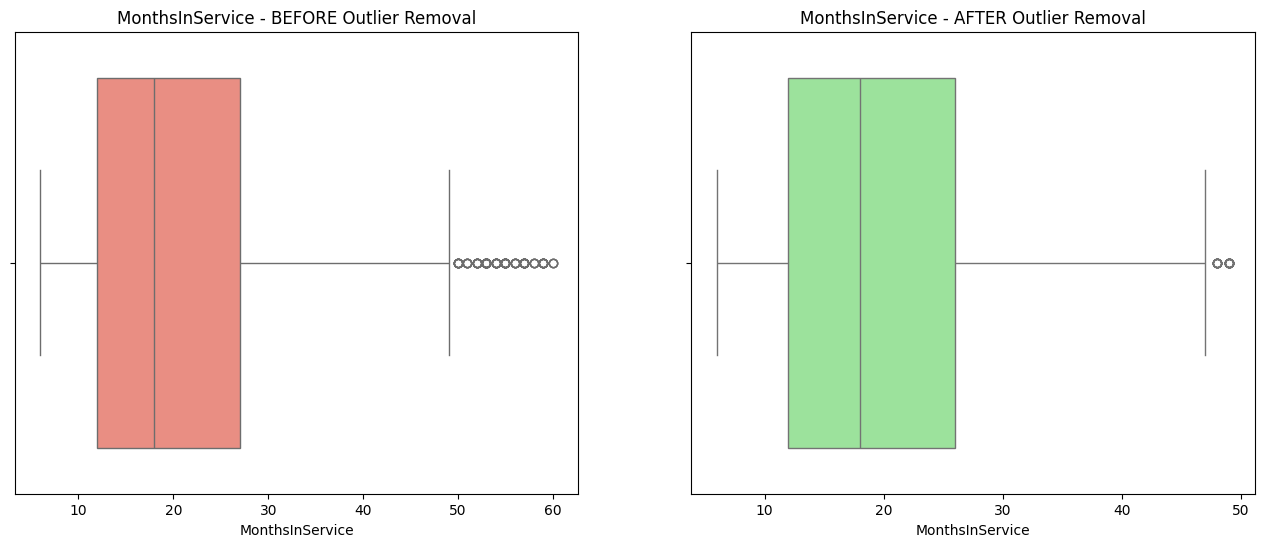


Processing Column: UniqueSubs

=== Outlier Report for: UniqueSubs ===
Lower Bound: -0.50
Upper Bound: 3.50
Total Outliers: 185
Rows before: 4958, Rows after: 4773


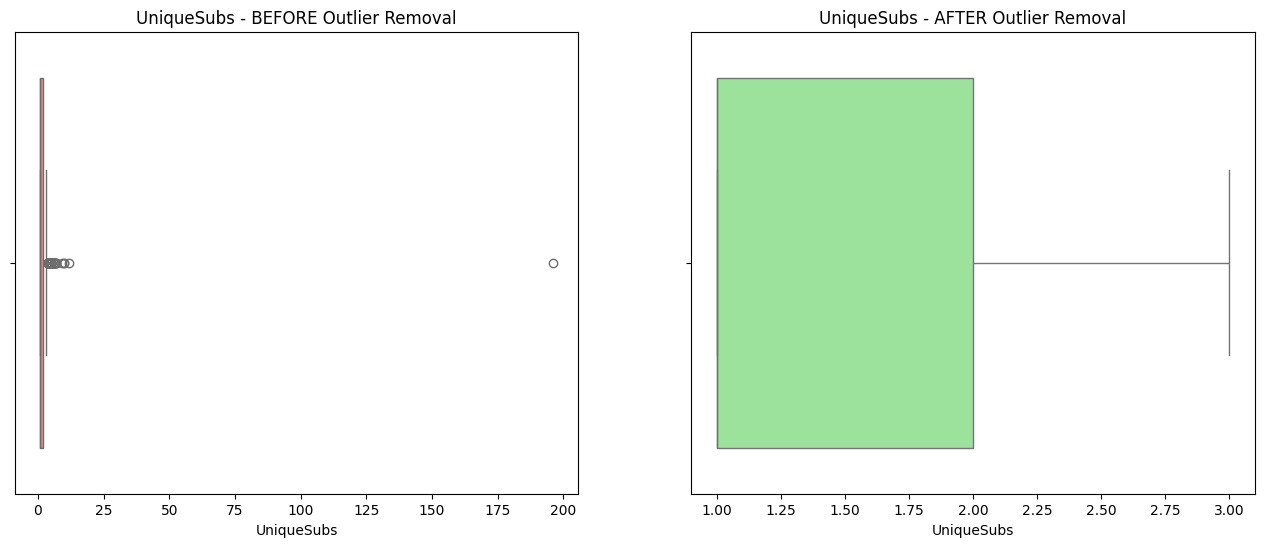


Processing Column: ActiveSubs

=== Outlier Report for: ActiveSubs ===
Lower Bound: -0.50
Upper Bound: 3.50
Total Outliers: 0
Rows before: 4773, Rows after: 4773


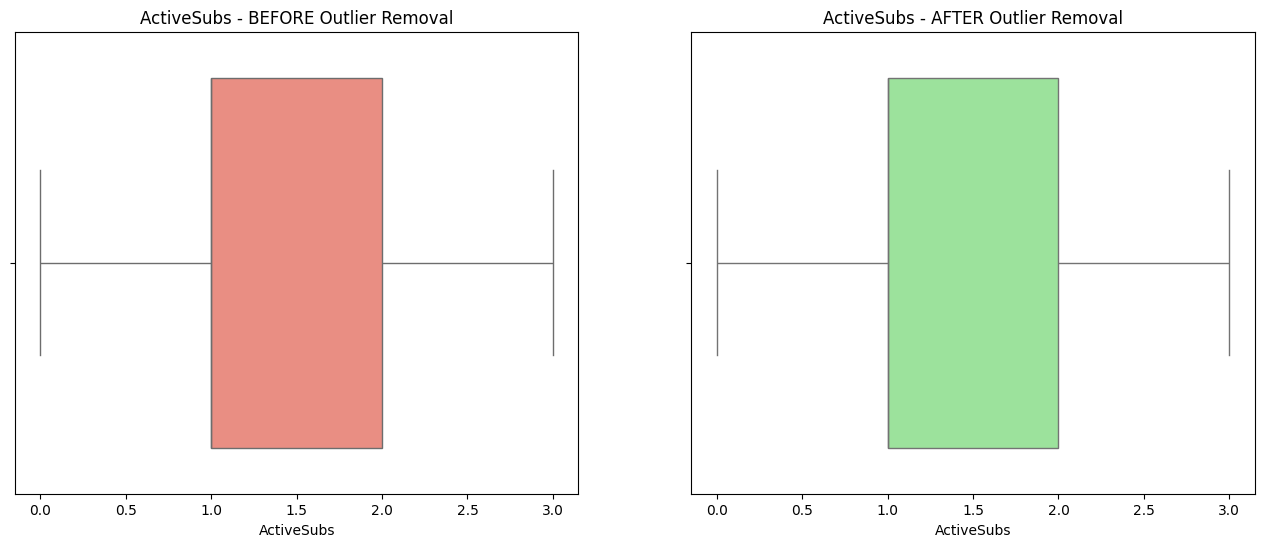


Processing Column: Handsets

=== Outlier Report for: Handsets ===
Lower Bound: 1.00
Upper Bound: 1.00
Total Outliers: 1048
Rows before: 4773, Rows after: 3725


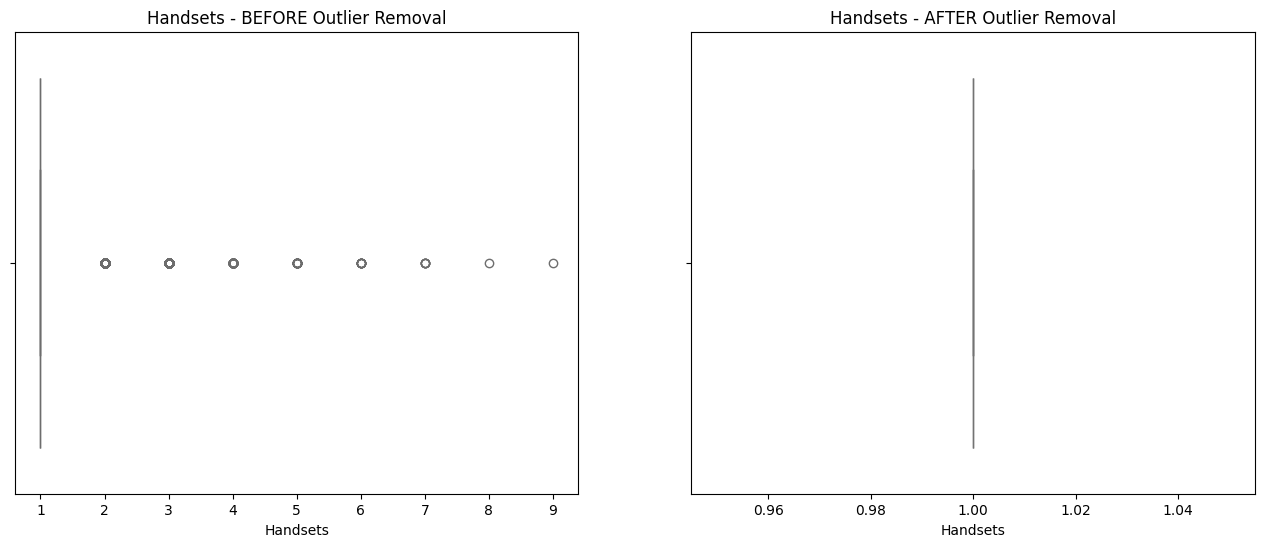


Processing Column: HandsetModels

=== Outlier Report for: HandsetModels ===
Lower Bound: 1.00
Upper Bound: 1.00
Total Outliers: 0
Rows before: 3725, Rows after: 3725


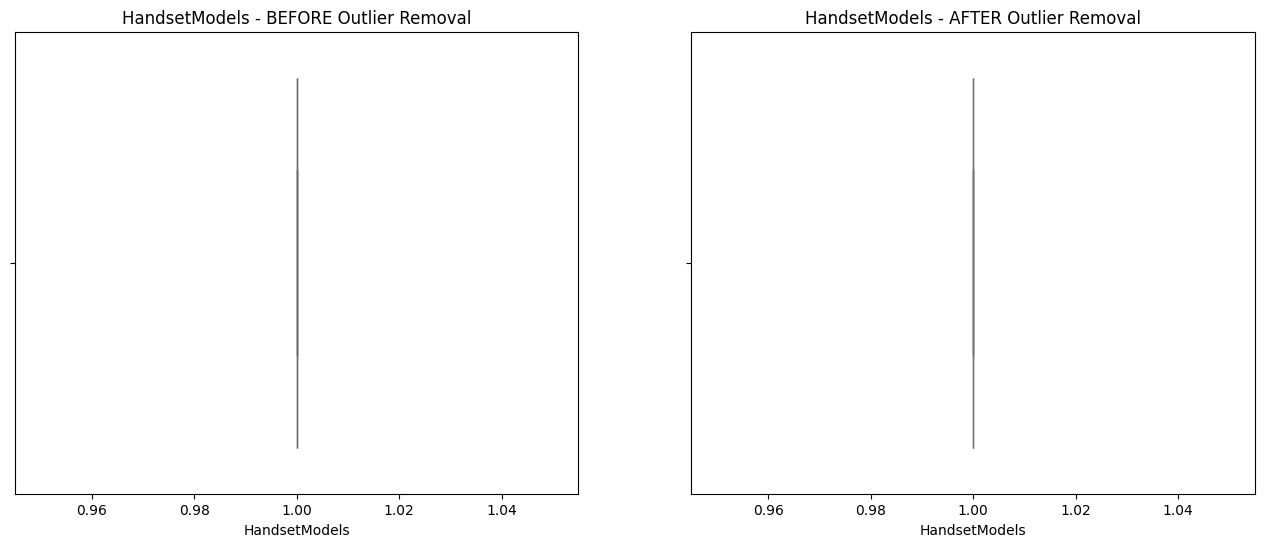


Processing Column: CurrentEquipmentDays

=== Outlier Report for: CurrentEquipmentDays ===
Lower Bound: -259.00
Upper Bound: 1325.00
Total Outliers: 47
Rows before: 3725, Rows after: 3678


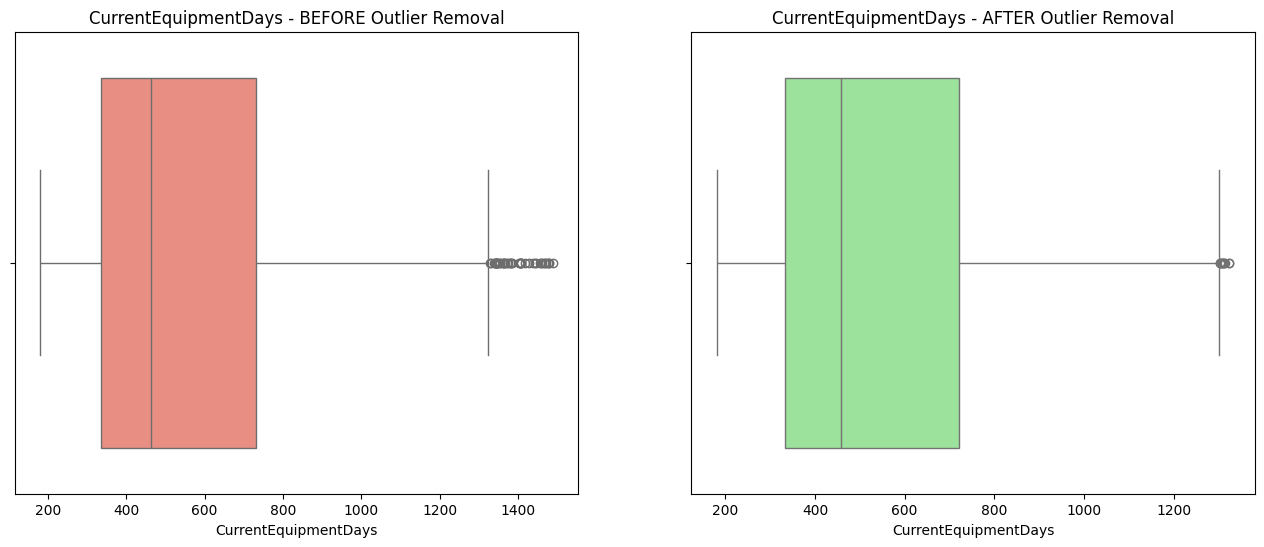


Processing Column: AgeHH1

=== Outlier Report for: AgeHH1 ===
Lower Bound: -6.00
Upper Bound: 90.00
Total Outliers: 4
Rows before: 3678, Rows after: 3674


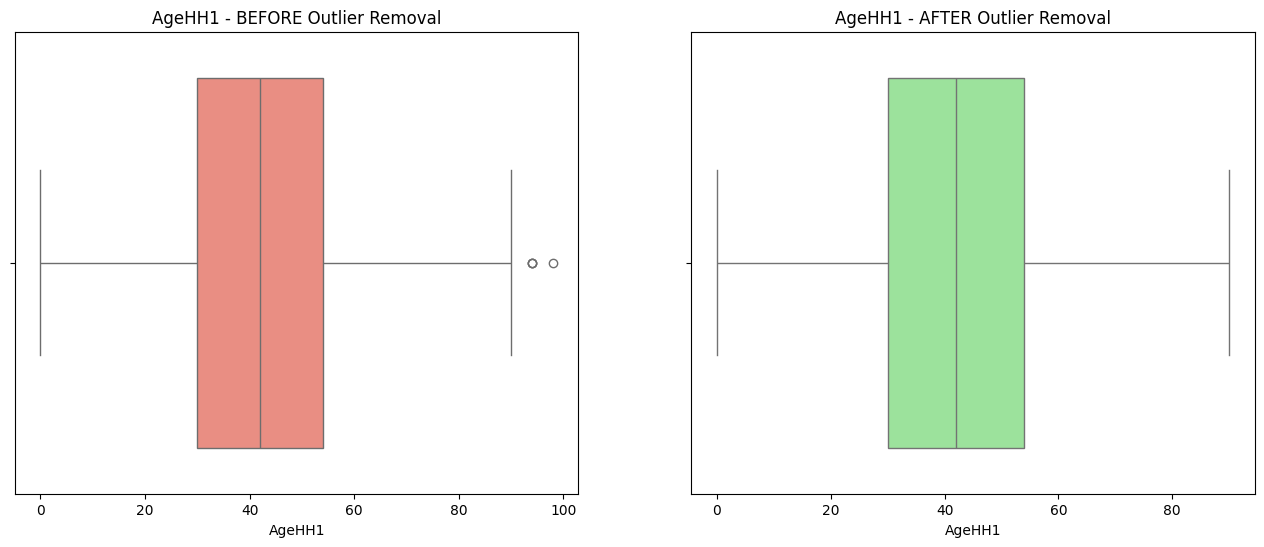


Processing Column: AgeHH2

=== Outlier Report for: AgeHH2 ===
Lower Bound: -75.00
Upper Bound: 125.00
Total Outliers: 0
Rows before: 3674, Rows after: 3674


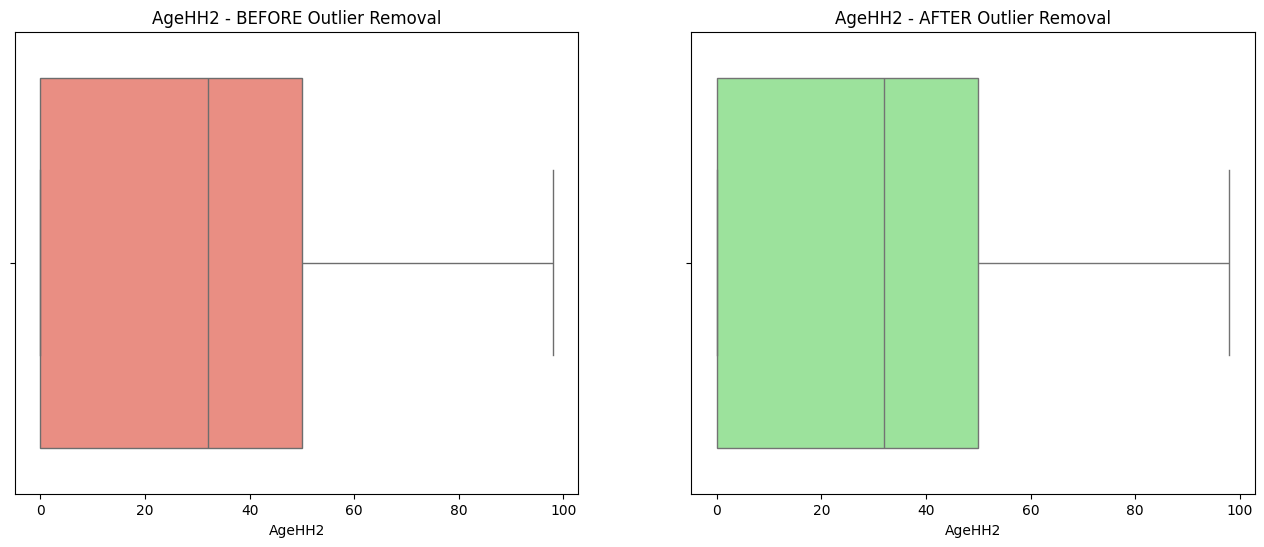


Processing Column: RetentionCalls

=== Outlier Report for: RetentionCalls ===
Lower Bound: 0.00
Upper Bound: 0.00
Total Outliers: 68
Rows before: 3674, Rows after: 3606


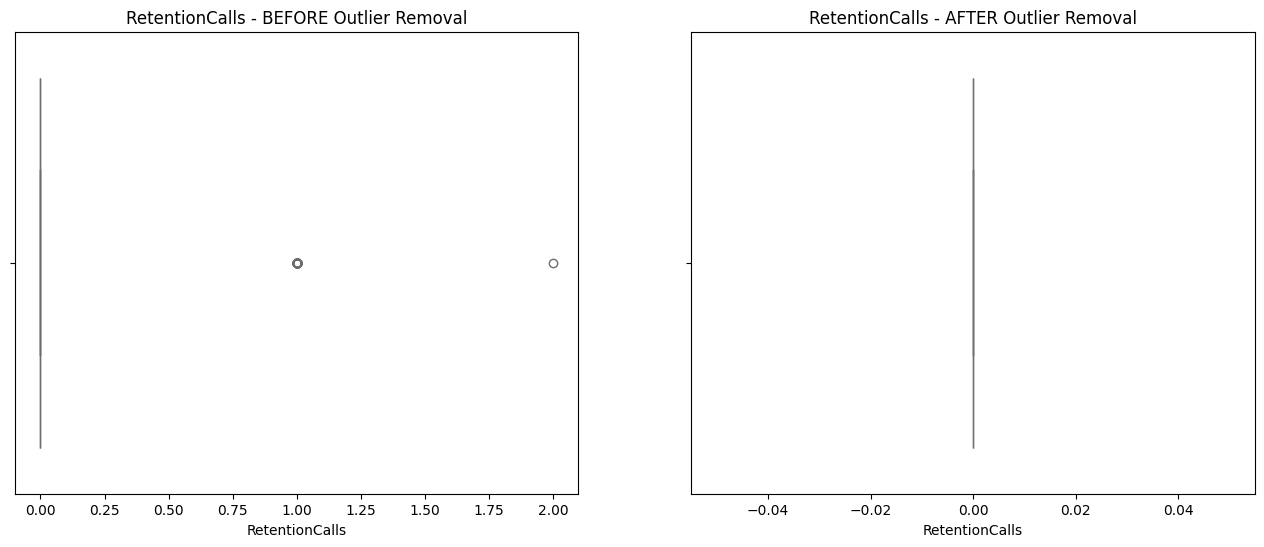


Processing Column: RetentionOffersAccepted

=== Outlier Report for: RetentionOffersAccepted ===
Lower Bound: 0.00
Upper Bound: 0.00
Total Outliers: 0
Rows before: 3606, Rows after: 3606


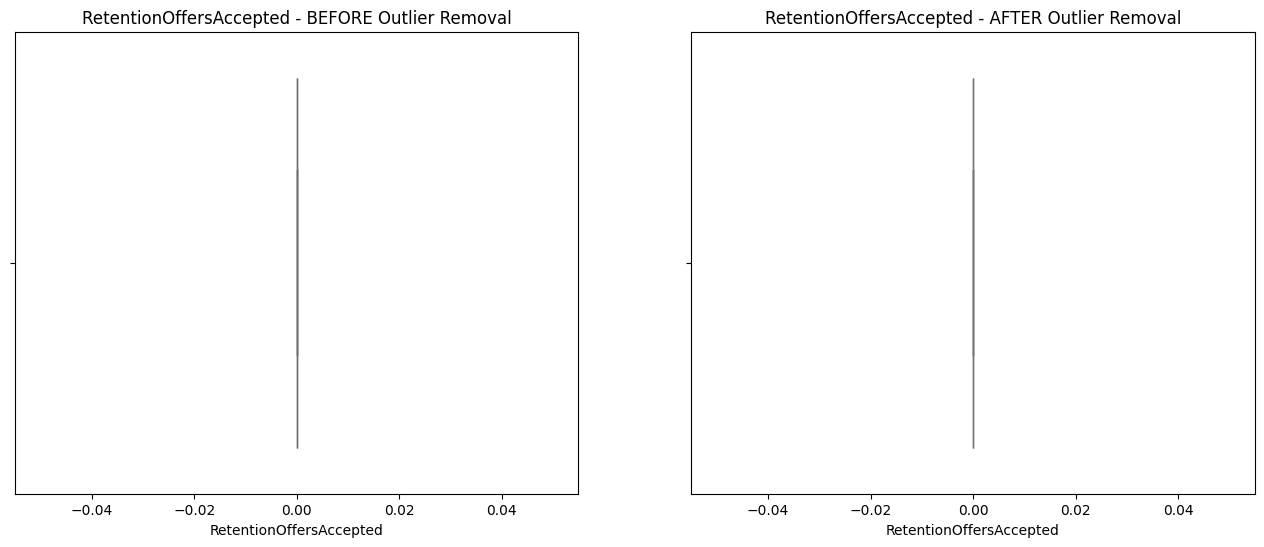


Processing Column: ReferralsMadeBySubscriber

=== Outlier Report for: ReferralsMadeBySubscriber ===
Lower Bound: 0.00
Upper Bound: 0.00
Total Outliers: 112
Rows before: 3606, Rows after: 3494


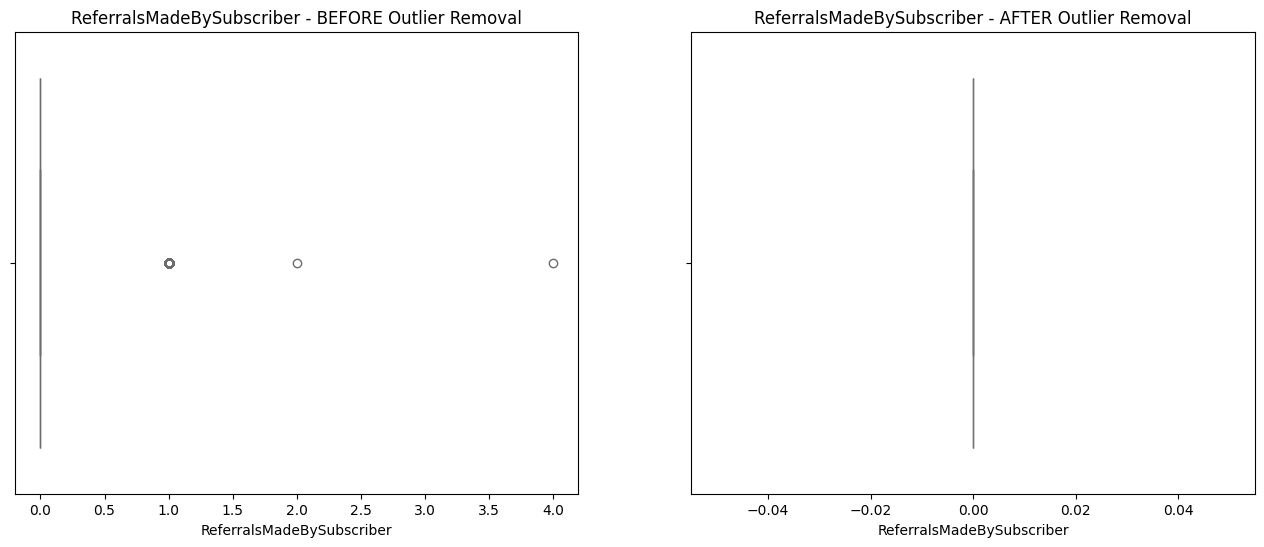


Processing Column: IncomeGroup

=== Outlier Report for: IncomeGroup ===
Lower Bound: -3.00
Upper Bound: 13.00
Total Outliers: 0
Rows before: 3494, Rows after: 3494


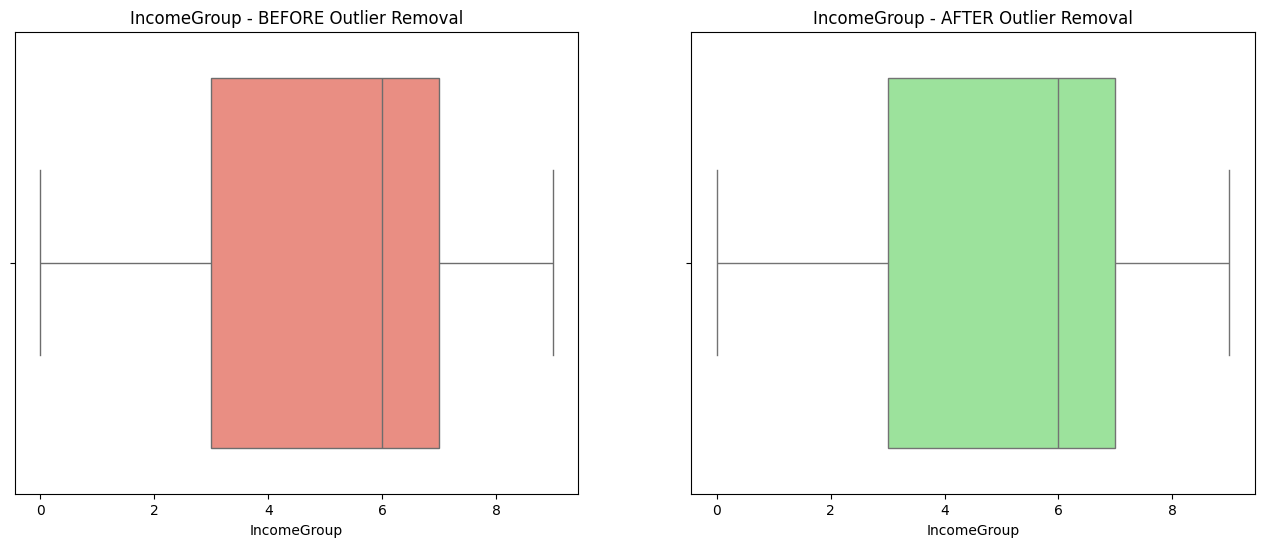


Processing Column: AdjustmentsToCreditRating

=== Outlier Report for: AdjustmentsToCreditRating ===
Lower Bound: 0.00
Upper Bound: 0.00
Total Outliers: 47
Rows before: 3494, Rows after: 3447


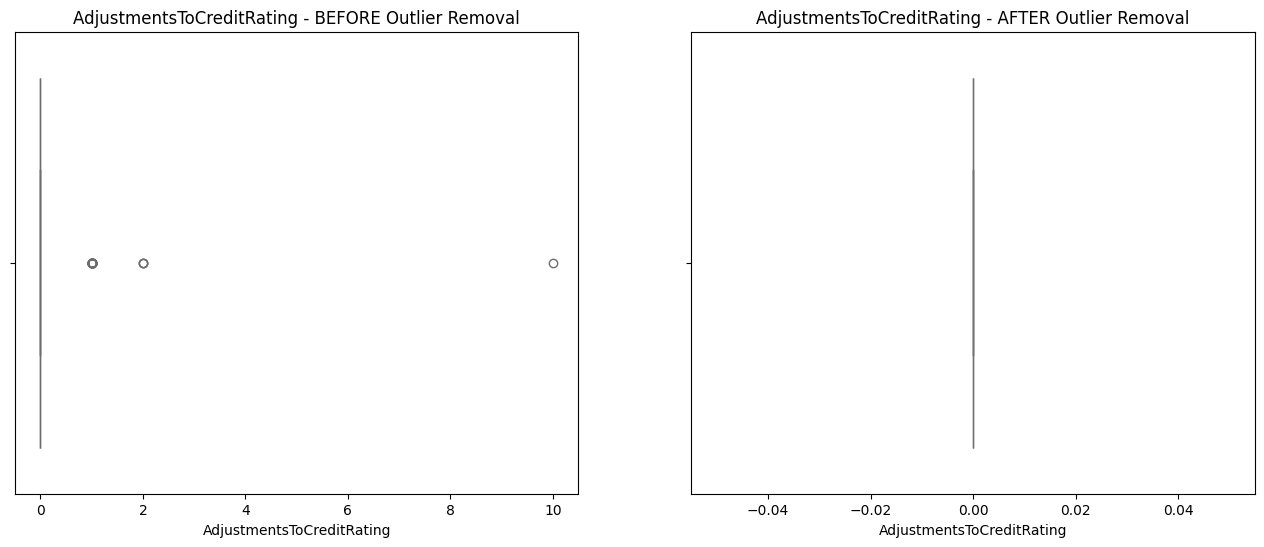

In [15]:
# ================= OUTLIER REMOVAL + VISUALIZATION (ONE CELL) =================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- FUNCTION: Detect outliers using IQR ----------
def detect_outliers_iqr(dt, column):
    Q1 = dt[column].quantile(0.25)
    Q3 = dt[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = dt[(dt[column] < lower) | (dt[column] > upper)]

    print(f"\n=== Outlier Report for: {column} ===")
    print(f"Lower Bound: {lower:.2f}")
    print(f"Upper Bound: {upper:.2f}")
    print(f"Total Outliers: {len(outliers)}")

    return outliers, lower, upper


# ---------- FUNCTION: Visualize (before & after removal) ----------
def visualize_outlier_removal(dt_original, dt_cleaned, column):
    plt.figure(figsize=(16,6))

    # Before removal
    plt.subplot(1, 2, 1)
    sns.boxplot(x=dt_original[column], color="salmon")
    plt.title(f"{column} - BEFORE Outlier Removal")

    # After removal
    plt.subplot(1, 2, 2)
    sns.boxplot(x=dt_cleaned[column], color="lightgreen")
    plt.title(f"{column} - AFTER Outlier Removal")

    plt.show()


# ---------- REMOVE OUTLIERS USING IQR ----------
def remove_outliers_iqr(dt, column):
    outliers, lower, upper = detect_outliers_iqr(dt, column)
    cleaned = dt[(dt[column] >= lower) & (dt[column] <= upper)]
    print(f"Rows before: {len(dt)}, Rows after: {len(cleaned)}")
    return cleaned


# ---------- RUN ON ALL NUMERIC COLUMNS ----------
numeric_cols = dt.select_dtypes(include=['int64', 'float64']).columns

# Copy original dataframe for comparison
dt_cleaned = dt.copy()

for col in numeric_cols:
    print("\n====================================")
    print(f"Processing Column: {col}")

    # Store before removal
    before = dt_cleaned.copy()

    # Remove outliers
    dt_cleaned = remove_outliers_iqr(dt_cleaned, col)

    # Visualize before & after for each column
    visualize_outlier_removal(before, dt_cleaned, col)


# dt_cleaned now contains the dataset WITHOUT outliers
# ================= END OF CELL =================



In [86]:
 dt_cleaned.shape

(3447, 58)

In [87]:
dt.shape

(51047, 68)

In [16]:
# Calculate summary statistics
dt.describe(include="all")


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
count,5.104700e+04,51047,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,...,51047.000000,51047.000000,51047,51047.000000,51047,51047,51047,51047,51047,51047
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2,NaN,16,2,7,4,8,3
top,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,No,NaN,Unknown,No,2-High,Other,Other,Unknown
freq,NaN,36336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,50368,NaN,28982,49302,18993,24655,37637,19700
mean,3.201957e+06,NaN,58.802788,525.165514,46.824495,0.893257,39.914628,1.232466,-11.500833,-1.185572,...,0.052070,4.324524,NaN,0.053911,NaN,NaN,NaN,NaN,NaN,NaN
std,1.169056e+05,NaN,44.442964,529.134170,23.812615,2.225423,96.462028,9.803517,256.587986,39.432467,...,0.307592,3.138236,NaN,0.383147,NaN,NaN,NaN,NaN,NaN,NaN
min,3.000002e+06,NaN,-6.170000,0.000000,-11.000000,0.000000,0.000000,0.000000,-3875.000000,-1107.700000,...,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,3.100632e+06,NaN,33.660000,159.000000,30.000000,0.000000,0.000000,0.000000,-82.000000,-6.900000,...,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,3.201534e+06,NaN,48.460000,366.000000,45.000000,0.250000,3.000000,0.000000,-5.000000,-0.300000,...,0.000000,5.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,3.305376e+06,NaN,70.960000,722.000000,60.000000,0.990000,40.000000,0.200000,65.000000,1.550000,...,0.000000,7.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
dt.nunique()

CustomerID                   51047
Churn                            2
MonthlyRevenue               12665
MonthlyMinutes                2719
TotalRecurringCharge           214
DirectorAssistedCalls          146
OverageMinutes                 746
RoamingCalls                   530
PercChangeMinutes             2262
PercChangeRevenues            2899
DroppedCalls                   285
BlockedCalls                   373
UnansweredCalls                840
CustomerCareCalls              185
ThreewayCalls                   78
ReceivedCalls                 6121
OutboundCalls                  787
InboundCalls                   472
PeakCallsInOut                1839
OffPeakCallsInOut             1669
DroppedBlockedCalls            447
CallForwardingCalls             31
CallWaitingCalls               223
MonthsInService                 56
UniqueSubs                      15
ActiveSubs                      12
ServiceArea                    747
Handsets                        23
HandsetModels       

In [18]:
dt.isnull().values.any()


False

In [19]:
columns_with_unknown = dt.columns[(dt == "Unknown").any()]
columns_with_unknown


Index(['Homeownership', 'HandsetPrice', 'MaritalStatus'], dtype='object')

In [20]:
(dt == "Unknown").sum()



CustomerID                       0
Churn                            0
MonthlyRevenue                   0
MonthlyMinutes                   0
TotalRecurringCharge             0
DirectorAssistedCalls            0
OverageMinutes                   0
RoamingCalls                     0
PercChangeMinutes                0
PercChangeRevenues               0
DroppedCalls                     0
BlockedCalls                     0
UnansweredCalls                  0
CustomerCareCalls                0
ThreewayCalls                    0
ReceivedCalls                    0
OutboundCalls                    0
InboundCalls                     0
PeakCallsInOut                   0
OffPeakCallsInOut                0
DroppedBlockedCalls              0
CallForwardingCalls              0
CallWaitingCalls                 0
MonthsInService                  0
UniqueSubs                       0
ActiveSubs                       0
ServiceArea                      0
Handsets                         0
HandsetModels       

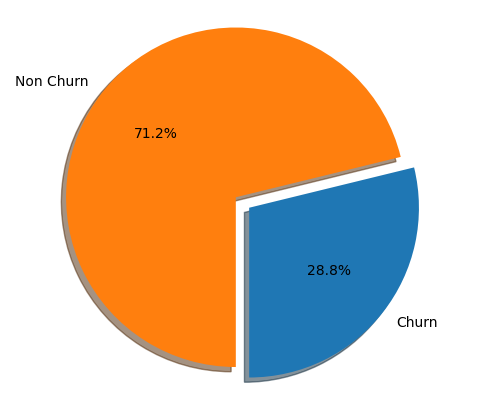

In [21]:
churn=dt[dt['Churn']=='Yes'].shape[0]
non_churn= dt[dt['Churn']=='No'].shape[0]

slices=[churn,non_churn]
labels=['Churn','Non Churn']
explode=[0.1,0]

fig1, ax1 = plt.subplots(figsize=(6, 5))
ax1.pie(slices,explode=explode, labels=labels,shadow=True,autopct='%1.1f%%',startangle=270 )
ax1.axis('equal')  
plt.show()

In [22]:
unique_count = {}

for column in dt.columns:
    unique_count[column] = dt[column].nunique()

unique_count


{'CustomerID': 51047,
 'Churn': 2,
 'MonthlyRevenue': 12665,
 'MonthlyMinutes': 2719,
 'TotalRecurringCharge': 214,
 'DirectorAssistedCalls': 146,
 'OverageMinutes': 746,
 'RoamingCalls': 530,
 'PercChangeMinutes': 2262,
 'PercChangeRevenues': 2899,
 'DroppedCalls': 285,
 'BlockedCalls': 373,
 'UnansweredCalls': 840,
 'CustomerCareCalls': 185,
 'ThreewayCalls': 78,
 'ReceivedCalls': 6121,
 'OutboundCalls': 787,
 'InboundCalls': 472,
 'PeakCallsInOut': 1839,
 'OffPeakCallsInOut': 1669,
 'DroppedBlockedCalls': 447,
 'CallForwardingCalls': 31,
 'CallWaitingCalls': 223,
 'MonthsInService': 56,
 'UniqueSubs': 15,
 'ActiveSubs': 12,
 'ServiceArea': 747,
 'Handsets': 23,
 'HandsetModels': 13,
 'CurrentEquipmentDays': 1438,
 'AgeHH1': 43,
 'AgeHH2': 43,
 'ChildrenInHH': 2,
 'HandsetRefurbished': 2,
 'HandsetWebCapable': 2,
 'TruckOwner': 2,
 'RVOwner': 2,
 'Homeownership': 2,
 'BuysViaMailOrder': 2,
 'RespondsToMailOffers': 2,
 'OptOutMailings': 2,
 'NonUSTravel': 2,
 'OwnsComputer': 2,
 'HasC

In [23]:
columns_with_no = dt.columns[
    dt.apply(lambda col: col.astype(str).str.startswith("No")).any()
]

columns_with_no


Index(['Churn', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable',
       'TruckOwner', 'RVOwner', 'BuysViaMailOrder', 'RespondsToMailOffers',
       'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard',
       'NewCellphoneUser', 'NotNewCellphoneUser', 'OwnsMotorcycle',
       'MadeCallToRetentionTeam', 'MaritalStatus'],
      dtype='object')

In [24]:
# ===================== SHOW ALL UNIQUE VALUES FOR EACH COLUMN =====================

for col in dt.columns:
    print(f"\n=============== Column: {col} ===============")
    unique_vals = dt[col].unique()
    print(f"Number of unique values: {len(unique_vals)}")
    print("Unique values:")
    print(unique_vals)

# =====================================================================



=============== Column: CustomerID ===============
Number of unique values: 51047
Unique values:
[3000002 3000010 3000014 ... 3399978 3399990 3399994]

=============== Column: Churn ===============
Number of unique values: 2
Unique values:
['Yes' 'No']

=============== Column: MonthlyRevenue ===============
Number of unique values: 12665
Unique values:
[ 24.    16.99  38.   ...  27.11 534.93 109.96]

=============== Column: MonthlyMinutes ===============
Number of unique values: 2719
Unique values:
[ 219.   10.    8. ... 3360. 4719. 2437.]

=============== Column: TotalRecurringCharge ===============
Number of unique values: 214
Unique values:
[ 22.  17.  38.  75.  52.  30.  66.  35.  25.  85.  37.  60.  70. 100.
  50.  55.  68.  20.  45. 150.  83.  19.  71.  15.  58.  89.  95.  78.
  80.  77. 183. 213.  87.  27. 108.  32.  59.   5.  40.  10. 105. 107.
  74. 102. 140.  63.  93. 202.  49.  48.  81.  57.  24.  21.  47.  97.
 160. 110.  82.  42.  36. 115.  76.   7. 200. 207.  31.  92. 10

In [25]:
"""
=============== Column: Homeownership ===============
Number of unique values: 2
Unique values:
['Known' 'Unknown']

=============== Column: HandsetPrice ===============
Number of unique values: 16
Unique values:
['30' 'Unknown' '10' '80' '150' '300' '40' '200' '100' '130' '60' '400'
 '240' '250' '180' '500'] 

=============== Column: CreditRating ===============
Number of unique values: 7
Unique values:
['1-Highest' '4-Medium' '3-Good' '6-VeryLow' '2-High' '5-Low' '7-Lowest']

=============== Column: PrizmCode ===============
Number of unique values: 4
Unique values:
['Suburban' 'Town' 'Other' 'Rural']

=============== Column: Occupation ===============
Number of unique values: 8
Unique values:
['Professional' 'Crafts' 'Other' 'Self' 'Retired' 'Homemaker' 'Clerical'
 'Student']    

=============== Column: MaritalStatus ===============
Number of unique values: 3
Unique values:
['No' 'Yes' 'Unknown']  

"""

"\n=============== Column: Homeownership ===============\nNumber of unique values: 2\nUnique values:\n['Known' 'Unknown']\n\n=============== Column: HandsetPrice ===============\nNumber of unique values: 16\nUnique values:\n['30' 'Unknown' '10' '80' '150' '300' '40' '200' '100' '130' '60' '400'\n '240' '250' '180' '500'] \n\n=============== Column: CreditRating ===============\nNumber of unique values: 7\nUnique values:\n['1-Highest' '4-Medium' '3-Good' '6-VeryLow' '2-High' '5-Low' '7-Lowest']\n\n=============== Column: PrizmCode ===============\nNumber of unique values: 4\nUnique values:\n['Suburban' 'Town' 'Other' 'Rural']\n\n=============== Column: Occupation ===============\nNumber of unique values: 8\nUnique values:\n['Professional' 'Crafts' 'Other' 'Self' 'Retired' 'Homemaker' 'Clerical'\n 'Student']    \n\n=============== Column: MaritalStatus ===============\nNumber of unique values: 3\nUnique values:\n['No' 'Yes' 'Unknown']  \n\n"

In [26]:
dt['Homeownership']=dt['Homeownership'].map({'Known':1,'Unknown':0})

In [27]:

dt['HandsetPrice']=dt['HandsetPrice'].replace('Unknown',np.nan)
    

In [28]:
dt['HandsetPrice'].head(10)

0     30
1     30
2    NaN
3     10
4     10
5     30
6     30
7     30
8     80
9     30
Name: HandsetPrice, dtype: object

In [29]:
# Extract numeric part before the hyphen and convert to integer
dt["CreditRating"] = dt["CreditRating"].str.extract(r"(\d+)").astype(int)

# Verify output
print(dt["CreditRating"].unique())
print(dt["CreditRating"].head(20))


[1 4 3 6 2 5 7]
0     1
1     4
2     3
3     4
4     1
5     3
6     1
7     1
8     1
9     3
10    1
11    4
12    3
13    3
14    3
15    1
16    1
17    3
18    1
19    4
Name: CreditRating, dtype: int64


In [30]:
for col in dt.columns:
    print(repr(col))


'CustomerID'
'Churn'
'MonthlyRevenue'
'MonthlyMinutes'
'TotalRecurringCharge'
'DirectorAssistedCalls'
'OverageMinutes'
'RoamingCalls'
'PercChangeMinutes'
'PercChangeRevenues'
'DroppedCalls'
'BlockedCalls'
'UnansweredCalls'
'CustomerCareCalls'
'ThreewayCalls'
'ReceivedCalls'
'OutboundCalls'
'InboundCalls'
'PeakCallsInOut'
'OffPeakCallsInOut'
'DroppedBlockedCalls'
'CallForwardingCalls'
'CallWaitingCalls'
'MonthsInService'
'UniqueSubs'
'ActiveSubs'
'ServiceArea'
'Handsets'
'HandsetModels'
'CurrentEquipmentDays'
'AgeHH1'
'AgeHH2'
'ChildrenInHH'
'HandsetRefurbished'
'HandsetWebCapable'
'TruckOwner'
'RVOwner'
'Homeownership'
'BuysViaMailOrder'
'RespondsToMailOffers'
'OptOutMailings'
'NonUSTravel'
'OwnsComputer'
'HasCreditCard'
'RetentionCalls'
'RetentionOffersAccepted'
'NewCellphoneUser'
'NotNewCellphoneUser'
'ReferralsMadeBySubscriber'
'IncomeGroup'
'OwnsMotorcycle'
'AdjustmentsToCreditRating'
'HandsetPrice'
'MadeCallToRetentionTeam'
'CreditRating'
'PrizmCode'
'Occupation'
'MaritalStatus'


In [31]:
dt = pd.get_dummies(dt, columns=["Occupation"], drop_first=False)


In [32]:
dt = pd.get_dummies(dt, columns=["MaritalStatus"], drop_first=False)


In [33]:
dt.head(10)


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,Occupation_Crafts,Occupation_Homemaker,Occupation_Other,Occupation_Professional,Occupation_Retired,Occupation_Self,Occupation_Student,MaritalStatus_No,MaritalStatus_Unknown,MaritalStatus_Yes
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,False,False,False,True,False,False,False,True,False,False
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,False,False,False,True,False,False,False,False,False,True
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,True,False,False,False,False,False,False,False,False,True
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,False,False,True,False,False,False,False,True,False,False
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,False,False,False,True,False,False,False,False,False,True
5,3000030,No,38.05,682.0,52.0,0.25,0.0,0.0,148.0,-3.1,...,False,False,True,False,False,False,False,False,False,True
6,3000038,No,31.66,26.0,30.0,0.25,0.0,0.0,60.0,4.0,...,False,False,False,False,False,True,False,False,False,True
7,3000042,No,62.13,98.0,66.0,2.48,0.0,0.0,24.0,6.8,...,False,False,False,True,False,False,False,True,False,False
8,3000046,No,35.30,24.0,35.0,0.00,0.0,0.0,20.0,-0.3,...,False,False,True,False,False,False,False,False,False,True
9,3000050,No,81.00,1056.0,75.0,0.00,0.0,0.0,43.0,2.4,...,False,False,False,True,False,False,False,True,False,False


In [34]:
dt = dt.replace({'Yes':1,'No':0})
dt = dt.replace({True:1,False:0})

/var/folders/9m/6k4h87_55zq8p92n381x1djh0000gn/T/ipykernel_10533/4289441806.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dt = dt.replace({'Yes':1,'No':0})
/var/folders/9m/6k4h87_55zq8p92n381x1djh0000gn/T/ipykernel_10533/4289441806.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dt = dt.replace({True:1,False:0})


In [35]:
pd.set_option('display.max_columns', None)
dt.head(20)

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation_Clerical,Occupation_Crafts,Occupation_Homemaker,Occupation_Other,Occupation_Professional,Occupation_Retired,Occupation_Self,Occupation_Student,MaritalStatus_No,MaritalStatus_Unknown,MaritalStatus_Yes
0,3000002,1,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,SEAPOR503,2.0,2.0,361.0,62.0,0.0,0,0,1,0,0,1,1,1,0,0,1,1,1,0,0,0,0,4,0,0,30,1,1,Suburban,0,0,0,0,1,0,0,0,1,0,0
1,3000010,1,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,PITHOM412,2.0,1.0,1504.0,40.0,42.0,1,0,0,0,0,1,1,1,0,0,1,1,0,0,1,0,0,5,0,0,30,0,4,Suburban,0,0,0,0,1,0,0,0,0,0,1
2,3000014,0,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,MILMIL414,1.0,1.0,1812.0,26.0,26.0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,6,0,0,NaN,0,3,Town,0,1,0,0,0,0,0,0,0,0,1
3,3000022,0,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,PITHOM412,9.0,4.0,458.0,30.0,0.0,0,0,1,0,0,1,1,1,0,0,0,1,0,0,1,0,0,6,0,0,10,0,4,Other,0,0,0,1,0,0,0,0,1,0,0
4,3000026,1,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,OKCTUL918,4.0,3.0,852.0,46.0,54.0,0,0,0,0,0,1,1,1,0,0,1,1,0,0,0,1,0,9,0,1,10,0,1,Other,0,0,0,0,1,0,0,0,0,0,1
5,3000030,0,38.05,682.0,52.0,0.25,0.0,0.0,148.0,-3.1,9.0,1.7,13.0,0.7,0.0,42.2,6.7,0.0,33.3,53.0,10.7,0.0,0.7,53,1,1,OKCTUL918,3.0,2.0,231.0,28.0,0.0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,1,0,0,1,0,1,30,0,3,Other,0,0,0,1,0,0,0,0,0,0,1
6,3000038,0,31.66,26.0,30.0,0.25,0.0,0.0,60.0,4.0,0.0,1.0,2.3,0.0,0.0,0.0,0.0,0.0,1.7,1.7,1.0,0.0,0.0,57,2,2,OKCTUL918,2.0,2.0,601.0,52.0,58.0,0,0,1,0,0,1,1,1,0,1,0,1,0,0,0,1,0,9,0,1,30,0,1,Other,0,0,0,0,0,0,1,0,0,0,1
7,3000042,0,62.13,98.0,66.0,2.48,0.0,0.0,24.0,6.8,0.0,0.3,4.0,4.0,0.0,0.0,3.7,0.0,7.7,7.3,0.3,0.0,0.0,59,2,2,OKCOKC405,3.0,3.0,464.0,46.0,46.0,1,0,1,0,0,1,1,1,0,0,0,1,0,0,1,0,0,6,0,0,30,0,1,Other,0,0,0,0,1,0,0,0,1,0,0
8,3000046,0,35.30,24.0,35.0,0.00,0.0,0.0,20.0,-0.3,0.0,0.0,1.0,0.0,0.0,2.4,4.0,1.7,9.3,1.7,0.0,0.0,0.0,53,3,3,SANMCA210,4.0,3.0,544.0,36.0,34.0,1,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,9,0,0,80,0,1,Other,0,0,0,1,0,0,0,0,0,0,1
9,3000050,0,81.00,1056.0,75.0,0.00,0.0,0.0,43.0,2.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55,1,1,PITHOM412,9.0,5.0,388.0,46.0,68.0,0,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,5,0,1,30,0,3,Other,0,0,0,0,1,0,0,0,1,0,0


In [36]:
dt.dtypes

CustomerID                 int64
Churn                      int64
MonthlyRevenue           float64
MonthlyMinutes           float64
TotalRecurringCharge     float64
                          ...   
Occupation_Self            int64
Occupation_Student         int64
MaritalStatus_No           int64
MaritalStatus_Unknown      int64
MaritalStatus_Yes          int64
Length: 67, dtype: object

In [37]:
dt = dt.drop(columns=['ServiceArea'])

In [38]:
print("=== Column Data Types ===")
print(dt.dtypes)

print("\n=== Summary of Data Types ===")
print(dt.dtypes.value_counts())


=== Column Data Types ===
CustomerID                 int64
Churn                      int64
MonthlyRevenue           float64
MonthlyMinutes           float64
TotalRecurringCharge     float64
                          ...   
Occupation_Self            int64
Occupation_Student         int64
MaritalStatus_No           int64
MaritalStatus_Unknown      int64
MaritalStatus_Yes          int64
Length: 66, dtype: object

=== Summary of Data Types ===
int64      38
float64    26
object      2
Name: count, dtype: int64


In [39]:
dt['PrizmCode'].head(10)

0    Suburban
1    Suburban
2        Town
3       Other
4       Other
5       Other
6       Other
7       Other
8       Other
9       Other
Name: PrizmCode, dtype: object

In [40]:
dt['HandsetPrice'].nunique()

15

In [41]:
dt.head(10)

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation_Clerical,Occupation_Crafts,Occupation_Homemaker,Occupation_Other,Occupation_Professional,Occupation_Retired,Occupation_Self,Occupation_Student,MaritalStatus_No,MaritalStatus_Unknown,MaritalStatus_Yes
0,3000002,1,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,2.0,2.0,361.0,62.0,0.0,0,0,1,0,0,1,1,1,0,0,1,1,1,0,0,0,0,4,0,0,30,1,1,Suburban,0,0,0,0,1,0,0,0,1,0,0
1,3000010,1,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,2.0,1.0,1504.0,40.0,42.0,1,0,0,0,0,1,1,1,0,0,1,1,0,0,1,0,0,5,0,0,30,0,4,Suburban,0,0,0,0,1,0,0,0,0,0,1
2,3000014,0,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,1.0,1.0,1812.0,26.0,26.0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,6,0,0,NaN,0,3,Town,0,1,0,0,0,0,0,0,0,0,1
3,3000022,0,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,9.0,4.0,458.0,30.0,0.0,0,0,1,0,0,1,1,1,0,0,0,1,0,0,1,0,0,6,0,0,10,0,4,Other,0,0,0,1,0,0,0,0,1,0,0
4,3000026,1,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,4.0,3.0,852.0,46.0,54.0,0,0,0,0,0,1,1,1,0,0,1,1,0,0,0,1,0,9,0,1,10,0,1,Other,0,0,0,0,1,0,0,0,0,0,1
5,3000030,0,38.05,682.0,52.0,0.25,0.0,0.0,148.0,-3.1,9.0,1.7,13.0,0.7,0.0,42.2,6.7,0.0,33.3,53.0,10.7,0.0,0.7,53,1,1,3.0,2.0,231.0,28.0,0.0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,1,0,0,1,0,1,30,0,3,Other,0,0,0,1,0,0,0,0,0,0,1
6,3000038,0,31.66,26.0,30.0,0.25,0.0,0.0,60.0,4.0,0.0,1.0,2.3,0.0,0.0,0.0,0.0,0.0,1.7,1.7,1.0,0.0,0.0,57,2,2,2.0,2.0,601.0,52.0,58.0,0,0,1,0,0,1,1,1,0,1,0,1,0,0,0,1,0,9,0,1,30,0,1,Other,0,0,0,0,0,0,1,0,0,0,1
7,3000042,0,62.13,98.0,66.0,2.48,0.0,0.0,24.0,6.8,0.0,0.3,4.0,4.0,0.0,0.0,3.7,0.0,7.7,7.3,0.3,0.0,0.0,59,2,2,3.0,3.0,464.0,46.0,46.0,1,0,1,0,0,1,1,1,0,0,0,1,0,0,1,0,0,6,0,0,30,0,1,Other,0,0,0,0,1,0,0,0,1,0,0
8,3000046,0,35.30,24.0,35.0,0.00,0.0,0.0,20.0,-0.3,0.0,0.0,1.0,0.0,0.0,2.4,4.0,1.7,9.3,1.7,0.0,0.0,0.0,53,3,3,4.0,3.0,544.0,36.0,34.0,1,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,9,0,0,80,0,1,Other,0,0,0,1,0,0,0,0,0,0,1
9,3000050,0,81.00,1056.0,75.0,0.00,0.0,0.0,43.0,2.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55,1,1,9.0,5.0,388.0,46.0,68.0,0,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,5,0,1,30,0,3,Other,0,0,0,0,1,0,0,0,1,0,0


In [42]:
dt = pd.get_dummies(dt, columns=["PrizmCode"], drop_first=False)


In [43]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 69 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  int64  
 2   MonthlyRevenue             51047 non-null  float64
 3   MonthlyMinutes             51047 non-null  float64
 4   TotalRecurringCharge       51047 non-null  float64
 5   DirectorAssistedCalls      51047 non-null  float64
 6   OverageMinutes             51047 non-null  float64
 7   RoamingCalls               51047 non-null  float64
 8   PercChangeMinutes          51047 non-null  float64
 9   PercChangeRevenues         51047 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

In [44]:
for v in dt["HandsetPrice"].unique():
    print((v))


30
nan
10
80
150
300
40
200
100
130
60
400
240
250
180
500


In [45]:
dt["HandsetPrice"] = pd.to_numeric(dt["HandsetPrice"], errors="coerce")
dt["HandsetPrice"] = dt["HandsetPrice"].fillna(dt["HandsetPrice"].median())


In [46]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 69 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  int64  
 2   MonthlyRevenue             51047 non-null  float64
 3   MonthlyMinutes             51047 non-null  float64
 4   TotalRecurringCharge       51047 non-null  float64
 5   DirectorAssistedCalls      51047 non-null  float64
 6   OverageMinutes             51047 non-null  float64
 7   RoamingCalls               51047 non-null  float64
 8   PercChangeMinutes          51047 non-null  float64
 9   PercChangeRevenues         51047 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

In [47]:
dt['PrizmCode_Other'].head

<bound method NDFrame.head of 0        False
1        False
2        False
3         True
4         True
         ...  
51042    False
51043     True
51044     True
51045     True
51046     True
Name: PrizmCode_Other, Length: 51047, dtype: bool>

In [48]:
dt = dt.replace({True:1,False:0})

/var/folders/9m/6k4h87_55zq8p92n381x1djh0000gn/T/ipykernel_10533/692473865.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dt = dt.replace({True:1,False:0})


In [49]:
dt=dt.drop(columns=['CustomerID'])

In [50]:
dt.head()

,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,Occupation_Clerical,Occupation_Crafts,Occupation_Homemaker,Occupation_Other,Occupation_Professional,Occupation_Retired,Occupation_Self,Occupation_Student,MaritalStatus_No,MaritalStatus_Unknown,MaritalStatus_Yes,PrizmCode_Other,PrizmCode_Rural,PrizmCode_Suburban,PrizmCode_Town
0,1,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,2.0,2.0,361.0,62.0,0.0,0,0,1,0,0,1,1,1,0,0,1,1,1,0,0,0,0,4,0,0,30.0,1,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0
1,1,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,2.0,1.0,1504.0,40.0,42.0,1,0,0,0,0,1,1,1,0,0,1,1,0,0,1,0,0,5,0,0,30.0,0,4,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0
2,0,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,1.0,1.0,1812.0,26.0,26.0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,6,0,0,60.0,0,3,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1
3,0,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,9.0,4.0,458.0,30.0,0.0,0,0,1,0,0,1,1,1,0,0,0,1,0,0,1,0,0,6,0,0,10.0,0,4,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0
4,1,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,4.0,3.0,852.0,46.0,54.0,0,0,0,0,0,1,1,1,0,0,1,1,0,0,0,1,0,9,0,1,10.0,0,1,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0


In [51]:
X=dt.iloc[:,1:]
y=dt.iloc[:,0]

In [52]:
X.head()

,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,Occupation_Clerical,Occupation_Crafts,Occupation_Homemaker,Occupation_Other,Occupation_Professional,Occupation_Retired,Occupation_Self,Occupation_Student,MaritalStatus_No,MaritalStatus_Unknown,MaritalStatus_Yes,PrizmCode_Other,PrizmCode_Rural,PrizmCode_Suburban,PrizmCode_Town
0,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,2.0,2.0,361.0,62.0,0.0,0,0,1,0,0,1,1,1,0,0,1,1,1,0,0,0,0,4,0,0,30.0,1,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0
1,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,2.0,1.0,1504.0,40.0,42.0,1,0,0,0,0,1,1,1,0,0,1,1,0,0,1,0,0,5,0,0,30.0,0,4,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0
2,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,1.0,1.0,1812.0,26.0,26.0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,6,0,0,60.0,0,3,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1
3,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,9.0,4.0,458.0,30.0,0.0,0,0,1,0,0,1,1,1,0,0,0,1,0,0,1,0,0,6,0,0,10.0,0,4,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0
4,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,4.0,3.0,852.0,46.0,54.0,0,0,0,0,0,1,1,1,0,0,1,1,0,0,0,1,0,9,0,1,10.0,0,1,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0


In [53]:
y.head(6)

0    1
1    1
2    0
3    0
4    1
5    0
Name: Churn, dtype: int64

In [54]:
numeric_cols = dt.select_dtypes(include=['int64', 'float64']).columns
corr_target = dt[numeric_cols].corr()['Churn'].sort_values(ascending=False)
print(corr_target)


Churn                      1.000000
CurrentEquipmentDays       0.103690
MadeCallToRetentionTeam    0.067393
RetentionCalls             0.065301
RetentionOffersAccepted    0.034953
                             ...   
OffPeakCallsInOut         -0.040784
CreditRating              -0.044750
MonthlyMinutes            -0.050384
TotalRecurringCharge      -0.061254
HandsetWebCapable         -0.062096
Name: Churn, Length: 68, dtype: float64


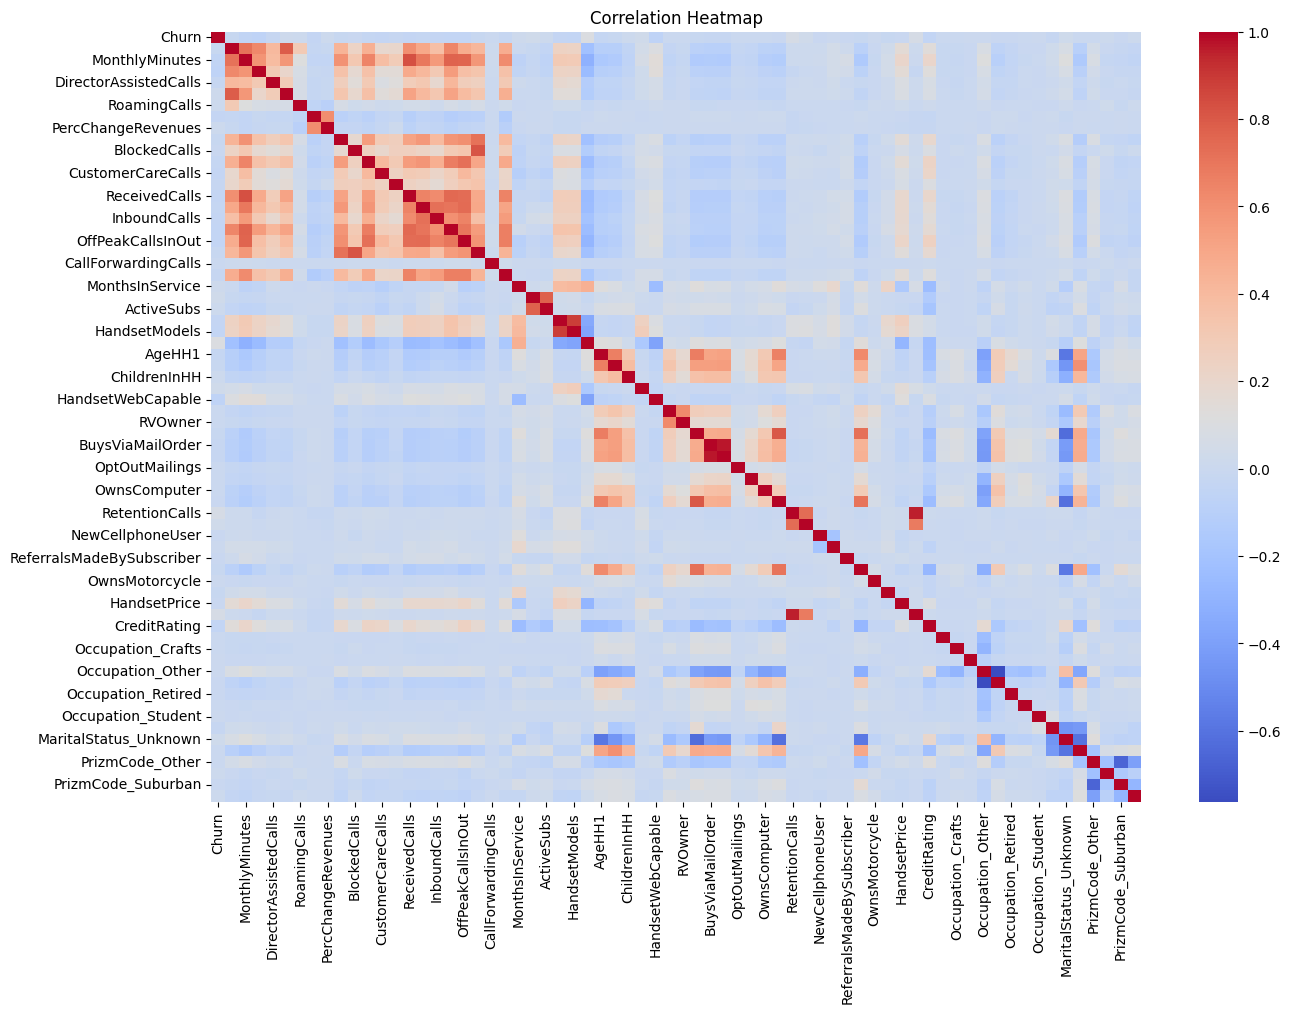

In [55]:
import seaborn as sns
plt.figure(figsize=(15,10))
sns.heatmap(dt[numeric_cols].corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()


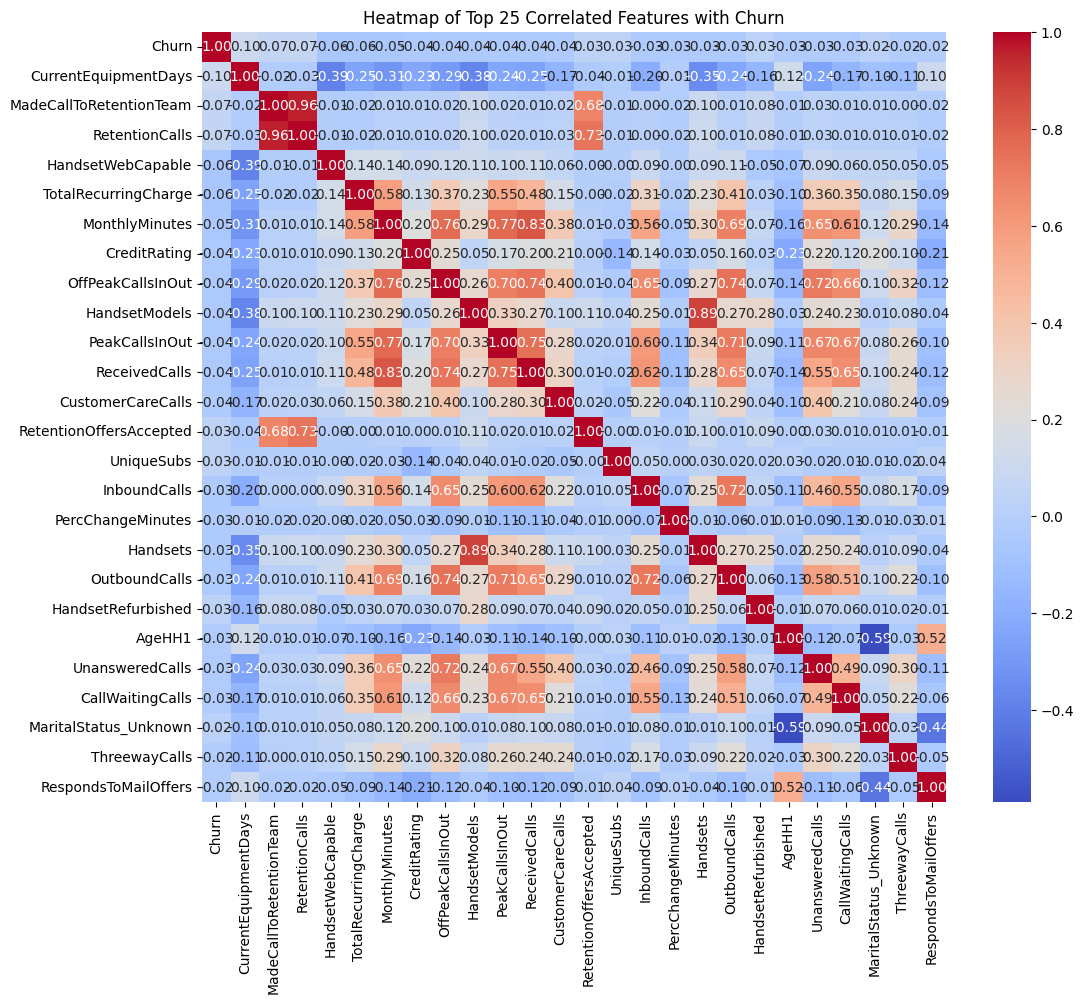

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select top 25 numeric correlated features
numeric_cols = dt.select_dtypes(include=['int64','float64']).columns
corr = dt[numeric_cols].corr()['Churn'].abs().sort_values(ascending=False)
top_25 = corr.head(26).index    # 26 because 'Churn' is included

# Plot heatmap for top 25
plt.figure(figsize=(12,10))
sns.heatmap(dt[top_25].corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.title('Heatmap of Top 25 Correlated Features with Churn')
plt.show()


In [57]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [79]:
X.describe()

,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,Occupation_Clerical,Occupation_Crafts,Occupation_Homemaker,Occupation_Other,Occupation_Professional,Occupation_Retired,Occupation_Self,Occupation_Student,MaritalStatus_No,MaritalStatus_Unknown,MaritalStatus_Yes,PrizmCode_Other,PrizmCode_Rural,PrizmCode_Suburban,PrizmCode_Town
count,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000
mean,58.802788,525.165514,46.824495,0.893257,39.914628,1.232466,-11.500833,-1.185572,6.011489,4.085672,28.288981,1.868999,0.298838,114.800121,25.377715,8.178104,90.549515,67.650790,10.158003,0.012277,1.840504,18.756264,1.532157,1.354340,1.805630,1.558740,380.544831,31.421141,20.767626,0.242287,0.138911,0.902031,0.186554,0.081356,0.665798,0.361451,0.376633,0.014732,0.056399,0.185398,0.675907,0.037201,0.018277,0.192450,0.137814,0.052070,4.324524,0.013301,0.053911,69.612318,0.034184,2.886967,0.019316,0.029757,0.003076,0.737301,0.171509,0.014359,0.017219,0.007464,0.248712,0.385919,0.365369,0.482986,0.047505,0.320842,0.148667
std,44.442964,529.134170,23.812615,2.225423,96.462028,9.803517,256.587986,39.432467,9.043955,10.946905,38.876194,5.096138,1.168277,166.485896,35.209147,16.665878,104.947470,92.752699,15.555284,0.594168,5.585129,9.800138,1.223384,0.675477,1.331165,0.905927,253.799599,21.905705,23.881611,0.428471,0.345857,0.297275,0.389557,0.273384,0.471715,0.480426,0.484546,0.120477,0.230693,0.388624,0.468040,0.206483,0.142458,0.394228,0.344708,0.307592,3.138236,0.114563,0.383147,41.210912,0.181704,1.583360,0.137633,0.169918,0.055373,0.440105,0.376956,0.118968,0.130089,0.086071,0.432271,0.486816,0.481538,0.499715,0.212719,0.466805,0.355763
min,-6.170000,0.000000,-11.000000,0.000000,0.000000,0.000000,-3875.000000,-1107.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,1.000000,0.000000,1.000000,1.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.660000,159.000000,30.000000,0.000000,0.000000,0.000000,-82.000000,-6.900000,0.700000,0.000000,5.300000,0.000000,0.000000,8.300000,3.300000,0

In [82]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (40837, 67)
X_test shape : (10210, 67)


In [58]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 67 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   MonthlyRevenue             51047 non-null  float64
 1   MonthlyMinutes             51047 non-null  float64
 2   TotalRecurringCharge       51047 non-null  float64
 3   DirectorAssistedCalls      51047 non-null  float64
 4   OverageMinutes             51047 non-null  float64
 5   RoamingCalls               51047 non-null  float64
 6   PercChangeMinutes          51047 non-null  float64
 7   PercChangeRevenues         51047 non-null  float64
 8   DroppedCalls               51047 non-null  float64
 9   BlockedCalls               51047 non-null  float64
 10  UnansweredCalls            51047 non-null  float64
 11  CustomerCareCalls          51047 non-null  float64
 12  ThreewayCalls              51047 non-null  float64
 13  ReceivedCalls              51047 non-null  flo

In [59]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy=0.6, random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=500,
        class_weight={0:1, 1:2},
        random_state=42,
        n_jobs=-1
    ))
])


In [60]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__max_depth': [8,10,12],
    'model__min_samples_split': [5,8,10]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring='f1',   # ← KEY CHANGE
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('smote',
                                        SMOTE(random_state=42,
                                              sampling_strategy=0.6)),
                                       ('model',
                                        RandomForestClassifier(class_weight={0: 1,
                                                                             1: 2},
                                                               n_estimators=500,
                                                               n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [8, 10, 12],
                         'model__min_samples_split': [5, 8, 10]},
             scoring='f1')

In [61]:
y_prob = grid.predict_proba(X_test)[:,1]


In [62]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_threshold = max(best_threshold, 0.35)

print("Best Threshold:", best_threshold)


Best Threshold: 0.4757256151200782


In [63]:
y_pred = (y_prob >= best_threshold).astype(int)


# Smote

In [65]:
from imblearn.over_sampling import SMOTE

#Create SMOTE object
smote = SMOTE(random_state=42)

# Fit + resample training data
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_sm.value_counts())


Before SMOTE:
Churn
0    29068
1    11769
Name: count, dtype: int64

After SMOTE:
Churn
0    29068
1    29068
Name: count, dtype: int64


In [66]:
from sklearn.preprocessing import  StandardScaler
import pandas as pd

from sklearn.preprocessing import  StandardScaler
scaler = StandardScaler()
scaler.fit(X_train_sm)

X_train_norm = pd.DataFrame(scaler.transform(X_train_sm), 
                            columns=X_train_sm.columns, 
                            index=X_train_sm.index)

X_test_norm = pd.DataFrame(scaler.transform(X_test), 
                           columns=X_test.columns, 
                           index=X_test.index)


## XGBOOST

In [ ]:
import random
from xgboost import XGBClassifier
seed = random.randint(0, 100000)



from collections import Counter

counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1]

print(scale_pos_weight)



xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.85,
    colsample_bytree=0.85,
    scale_pos_weight=scale_pos_weight,  
    random_state=42,
    eval_metric="auc",
    reg_lambda=2,
    reg_alpha=1
)


xgb.fit(X_train_norm, y_train_sm)
y_prob = xgb.predict_proba(X_test_norm)[:, 1]


In [70]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * precision * recall / (precision + recall + 1e-6)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
y_pred = (y_prob >= best_threshold).astype(int)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))


Best Threshold: 0.48775604
Accuracy : 0.5844270323212537
Precision: 0.38209171651259743
Recall   : 0.7165193745751189
F1 Score : 0.49840406667454784
ROC-AUC  : 0.6678402144262567


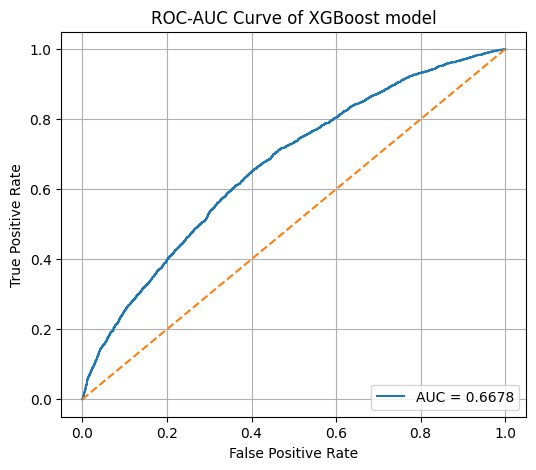

In [72]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Compute ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

# Compute AUC
roc_auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # Random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve of XGBoost model")
plt.legend(loc="lower right")

plt.grid(True)
plt.show()